# EXERCISES DM: Classifications
 
N.B. The exercises 1,3 and 6 come from examples given in <i>Hands-On Machine Learning 3rd Ed., A. Géron, O'Reilly, 2023, Chapter 4</i>, 
and were discussed during the course.

## DM 1 - Apprentissage automatique appliqué
## Fiche de TD « EXERCISES : Classifications » - questions 1 à 4

**Groupe :** ISMAIL ABDRAMAN Abdeldjabar — Khadidja AHMAT HASSAN

### Usage d'outils d'IA (à vérifier / compléter par le groupe)
| Outil (nom, version) | Technique / prompt | Éléments extraits |
|---|---|---|
| Claude Sonnet 5.5 (Anthropic, interface claude.ai) | Prompt : « Aide moi a interpreter les resultats des differents figures » + (génération guidée, une seule requête) | Structure du notebook, code des expériences supplémentaires, texte des commentaires. |

### Plan et démarche
Pour chaque exercice (1 à 4) : (i) on reproduit l'exemple de l'énoncé, (ii) on multiplie les expériences (features, espèces, tailles, déséquilibre, recouvrement, hyperparamètres `tol`, `max_iter`, `C`, `class_weight`, `alpha`, `learning_rate`, standardisation…), (iii) on **interprète** les résultats.

Remarques méthodologiques utilisées partout :
- partitions train/test **stratifiées** et graine fixée (`random_state=42`) pour la reproductibilité ;
- l'*accuracy* seule est trompeuse quand les classes sont déséquilibrées : on regarde aussi matrice de confusion, rappel, précision, F1 ;

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Binary 1D Classifiers on the Iris Dataset

### 1.1 Load the dataset

Load the standard iris dataset made available by `scikit`, and use some of the functions of `scikit` to observe this dataset.
In particular, `list(iris)` gives all the fields related to the dataset, then it is possible to call, e.g.: 
- `iris.data.head(10)`
- `print(iris.DESCR)`

and so on. 

In [2]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)

For instance:

In [3]:
print(list(iris))

['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']


In [4]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [5]:
print("Dimensions de iris.data :", iris.data.shape)
print("Noms des attributs      :", iris.feature_names)
print("Noms des classes        :", iris.target_names)

Dimensions de iris.data : (150, 4)
Noms des attributs      : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Noms des classes        : ['setosa' 'versicolor' 'virginica']


In [6]:
# Valeurs manquantes et types des données
iris.data.info()
print("Valeurs manquantes :", iris.data.isna().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
Valeurs manquantes : 0


In [7]:
# Statistiques descriptives du dataset
iris.data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [8]:
# Répartition des classes
iris.target.value_counts().sort_index().rename(dict(enumerate(iris.target_names)))

target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [9]:
# Statistiques par classe : les moyennes diffèrent-elles beaucoup entre espèces ?
df = iris.frame.copy()
df["espece"] = df["target"].map(dict(enumerate(iris.target_names)))
df.groupby("espece")[iris.feature_names].mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
espece,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [10]:
# Corrélations entre attributs
iris.data.corr().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.00,-0.12,0.87,0.82
sepal width (cm),-0.12,1.00,-0.43,-0.37
petal length (cm),0.87,-0.43,1.00,0.96
petal width (cm),0.82,-0.37,0.96,1.00


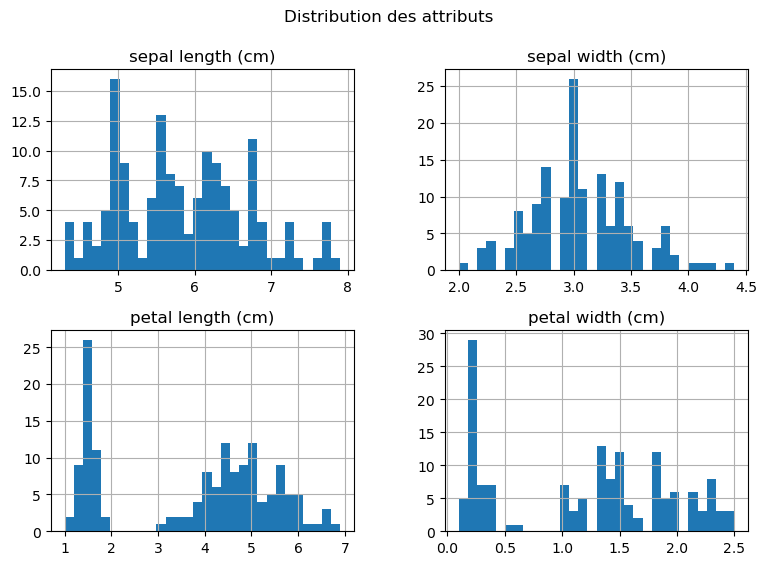

In [11]:
# Histogrammes par attribut
iris.data.hist(figsize=(9, 6), bins=30)
plt.suptitle("Distribution des attributs")
plt.show()

### Commentaires sur les résultats de 1.1

**Structure du jeu de données**
- `list(iris)` nous donne 8 champs : `data`, `target`, `frame`, `target_names`, `DESCR`, `feature_names`, `filename`, `data_module`.
- `iris.data` contient 150 exemples et 4 attributs numériques (`float64`) : longueur et largeur des sépales et des pétales, en cm.
- Il n'y a aucune valeur manquante (150 valeurs non nulles pour chaque colonne).

**Équilibre des classes**
- Les 3 classes (setosa, versicolor, virginica) ont exactement 50 exemples chacune.
- Le jeu est donc parfaitement équilibré : l'accuracy est une métrique pertinente ici.

**Statistiques descriptives**
- Les attributs ont des échelles différentes : `petal length` varie de 1.0 à 6.9 (écart-type 1.77), alors que `sepal width` varie de 2.0 à 4.4 (écart-type 0.44).
- `petal length` a un écart-type élevé et une médiane (4.35) très éloignée de son premier quartile (1.6). C'est le signe d'une distribution bimodale, liée à la présence d'une classe (setosa) aux pétales très petits. Même remarque pour `petal width` (médiane 1.3, premier quartile 0.3).
- Les échelles différentes pourront compter pour certains modèles sensibles à l'échelle (régression logistique avec régularisation). On pourra tester l'effet d'une standardisation (`StandardScaler`).

**Corrélations**
- `petal length` et `petal width` sont très fortement corrélées (0.96), et toutes deux le sont avec `sepal length` (0.87 et 0.82).
- `sepal width` est faiblement et négativement corrélée aux autres (de -0.12 à -0.43).
- Il y a donc de la redondance entre attributs : les coefficients de la régression logistique pourront être instables ou difficiles à interpréter attribut par attribut (multicolinéarité).

### 1.2 Generalization with a Logistic Regression
 
Obtain a generalization/model (based on a sigmoid-like score function) of a full binary 1D classification problem:
- to classify one kind of iris (Setosa, Versicolor, Virginica),
- from the two other kinds of iris
- by using only one of the feature (sepal length, sepal width, petal length, or petal width) as discriminant,
- by directly applying `LogisticRegression` of `scikit` (with at least a partition train/test).

Remark: this is the same as some examples shown in the course.

# Correction : virginica contre les autres, largeur des pétales

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

feature = "petal width (cm)"
X = iris.data[[feature]]                  # un seul attribut, problème 1D
y = (iris.target == 2).astype(int)        # 1 = virginica, 0 = les deux autres

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)

print("Accuracy train :", accuracy_score(y_train, clf.predict(X_train)))
print("Accuracy test  :", accuracy_score(y_test, clf.predict(X_test)))
print("Coefficient    :", clf.coef_[0][0])
print("Intercept      :", clf.intercept_[0])
print("Seuil de décision (proba = 0.5) :", -clf.intercept_[0] / clf.coef_[0][0])
print("Matrice de confusion:\n", confusion_matrix(y_test, clf.predict(X_test)))

Accuracy train : 0.9619047619047619
Accuracy test  : 0.9555555555555556
Coefficient    : 3.7550474397638958
Intercept      : -6.3060235219190055
Seuil de décision (proba = 0.5) : 1.6793458999057296
Matrice de confusion:
 [[30  0]
 [ 2 13]]


# cas 2 : visualisation de la sigmoïde

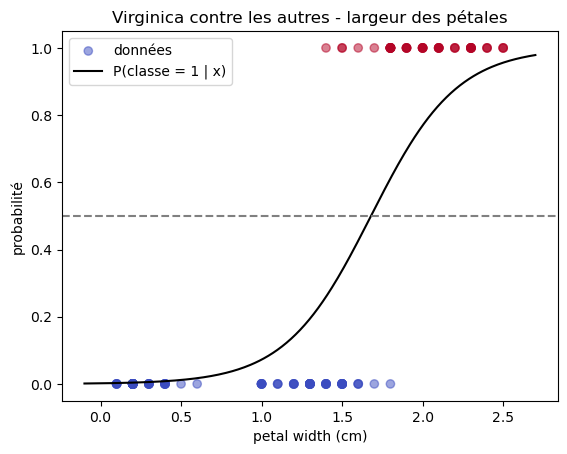

In [13]:
def trace_sigmoide(clf, X, y, feature, titre=""):
    xs = np.linspace(X[feature].min() - 0.2, X[feature].max() + 0.2, 300).reshape(-1, 1)
    xs_df = pd.DataFrame(xs, columns=[feature])
    plt.scatter(X[feature], y, c=y, cmap="coolwarm", alpha=0.5, label="données")
    plt.plot(xs, clf.predict_proba(xs_df)[:, 1], "k-", label="P(classe = 1 | x)")
    plt.axhline(0.5, color="gray", linestyle="--")
    plt.xlabel(feature); plt.ylabel("probabilité"); plt.title(titre)
    plt.legend(); plt.show()

trace_sigmoide(clf, X, y, feature, "Virginica contre les autres - largeur des pétales")

# Cas 3 : tous les couples (classe cible, attribut)
La moyenne est faite sur 30 partitions aléatoires pour ne pas dépendre d'un seul tirage.

In [14]:
resultats = pd.DataFrame(index=iris.target_names, columns=iris.feature_names, dtype=float)

for k, nom_classe in enumerate(iris.target_names):
    y_k = (iris.target == k).astype(int)
    for feat in iris.feature_names:
        scores = []
        for seed in range(30):
            Xtr, Xte, ytr, yte = train_test_split(iris.data[[feat]], y_k, test_size=0.3, stratify=y_k, random_state=seed)
            m = LogisticRegression().fit(Xtr, ytr)
            scores.append(m.score(Xte, yte))
        resultats.loc[nom_classe, feat] = np.mean(scores)

resultats.round(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,0.903,0.837,1.000,1.000
versicolor,0.663,0.719,0.637,0.664
virginica,0.794,0.661,0.943,0.959


In [15]:
# Référence : accuracy d'un classifieur qui prédit toujours "les autres"
print("Accuracy du classifieur trivial :", round(2/3, 3))

Accuracy du classifieur trivial : 0.667


# cas 4 : effet de l'aléa de la partition

Accuracy test : moyenne = 0.954, écart-type = 0.025, min = 0.911, max = 1.000


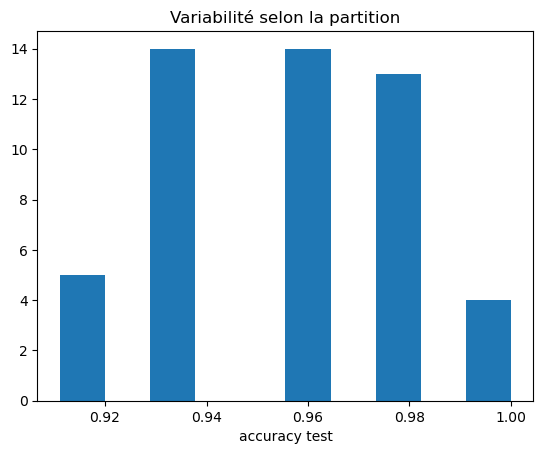

In [16]:
scores = []
for seed in range(50):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)
    scores.append(LogisticRegression().fit(Xtr, ytr).score(Xte, yte))

print(f"Accuracy test : moyenne = {np.mean(scores):.3f}, écart-type = {np.std(scores):.3f}, "
      f"min = {np.min(scores):.3f}, max = {np.max(scores):.3f}")
plt.hist(scores, bins=10); 
plt.xlabel("accuracy test"); 
plt.title("Variabilité selon la partition")
plt.show()

# cas 5 : effet de la cardinalité du jeu d'entraînement

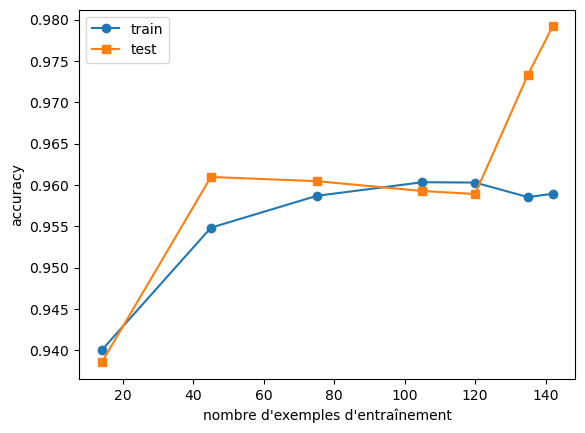

In [17]:
tailles = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]   # proportion du jeu utilisée pour le test
moy_train, moy_test = [], []
for t in tailles:
    a, b = [], []
    for seed in range(30):
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=t, stratify=y, random_state=seed)
        m = LogisticRegression().fit(Xtr, ytr)
        a.append(m.score(Xtr, ytr)); b.append(m.score(Xte, yte))
    moy_train.append(np.mean(a)); moy_test.append(np.mean(b))

n_train = [int(150 * (1 - t)) for t in tailles]
plt.plot(n_train, moy_train, "o-", label="train")
plt.plot(n_train, moy_test, "s-", label="test")
plt.xlabel("nombre d'exemples d'entraînement"); plt.ylabel("accuracy"); plt.legend(); plt.show()

# cas 6 : effet de l'hyperparamètre de régularisation C

In [70]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

lignes = []
for C in [0.01, 0.1, 1, 10, 100, 1e4]:
    m = LogisticRegression(C=C, max_iter=1000).fit(Xtr, ytr)
    lignes.append({"C": C, "coef": m.coef_[0][0], "intercept": m.intercept_[0],
                   "seuil": -m.intercept_[0] / m.coef_[0][0],
                   "acc_train": m.score(Xtr, ytr), "acc_test": m.score(Xte, yte)})
pd.DataFrame(lignes).round(3)

,C,coef,intercept,seuil,acc_train,acc_test
0,0.01,0.272,-1.021,3.759,0.667,0.667
1,0.10,1.380,-2.517,1.824,0.924,0.822
2,1.00,3.755,-6.306,1.679,0.962,0.956
3,10.00,8.104,-13.589,1.677,0.962,0.956
4,100.00,12.468,-20.892,1.676,0.962,0.956
5,10000.00,14.129,-23.674,1.676,0.962,0.956


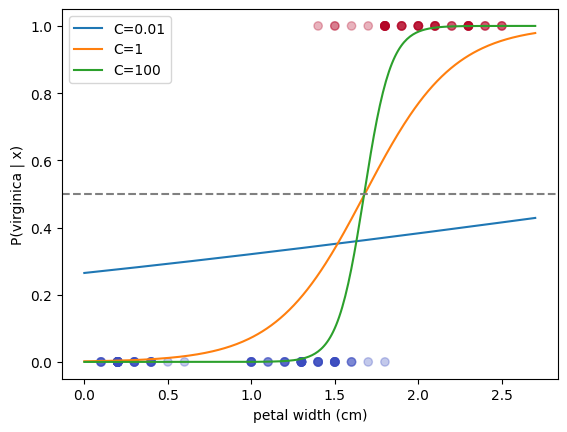

In [71]:
# Sigmoïdes obtenues pour plusieurs valeurs de C
xs = pd.DataFrame(np.linspace(0, 2.7, 300), columns=[feature])
for C in [0.01, 1, 100]:
    m = LogisticRegression(C=C, max_iter=1000).fit(Xtr, ytr)
    plt.plot(xs[feature], m.predict_proba(xs)[:, 1], label=f"C={C}")
plt.scatter(X[feature], y, c=y, cmap="coolwarm", alpha=0.3)
plt.axhline(0.5, color="gray", linestyle="--")
plt.xlabel(feature); plt.ylabel("P(virginica | x)"); plt.legend(); plt.show()

# cas 7 : cas linéairement séparable (setosa, longueur des pétales)

In [18]:
y_set = (iris.target == 0).astype(int)
Xtr, Xte, ytr, yte = train_test_split(iris.data[["petal length (cm)"]], y_set,
                                      test_size=0.3, stratify=y_set, random_state=42)
for C in [0.1, 1, 100, 1e4]:
    m = LogisticRegression(C=C, max_iter=1000).fit(Xtr, ytr)
    print(f"C={C:>8} | coef={m.coef_[0][0]:8.2f} | seuil={-m.intercept_[0]/m.coef_[0][0]:.2f} "
          f"| acc test={m.score(Xte, yte):.3f}")

C=     0.1 | coef=   -1.41 | seuil=2.73 | acc test=1.000
C=       1 | coef=   -2.71 | seuil=2.76 | acc test=1.000
C=     100 | coef=   -6.42 | seuil=2.65 | acc test=1.000
C= 10000.0 | coef=  -10.06 | seuil=2.66 | acc test=1.000


# cas 8 : effet de la standardisation et de class_weight

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import recall_score

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

for nom, modele in [
    ("défaut (C=1)", LogisticRegression()),
    ("standardisation", make_pipeline(StandardScaler(), LogisticRegression())),
    ("class_weight='balanced'", LogisticRegression(class_weight="balanced")),
    ("sans régularisation (C=np.inf)", LogisticRegression(C=np.inf, max_iter=1000)),
]:
    modele.fit(Xtr, ytr)
    pred = modele.predict(Xte)
    print(f"{nom:32s} | train={modele.score(Xtr, ytr):.3f} | test={modele.score(Xte, yte):.3f} "
          f"| rappel virginica={recall_score(yte, pred):.3f}")
    print(confusion_matrix(yte, pred))

défaut (C=1)                     | train=0.962 | test=0.956 | rappel virginica=0.867
[[30  0]
 [ 2 13]]
standardisation                  | train=0.962 | test=0.956 | rappel virginica=0.867
[[30  0]
 [ 2 13]]
class_weight='balanced'          | train=0.943 | test=0.956 | rappel virginica=0.867
[[30  0]
 [ 2 13]]
sans régularisation (C=np.inf)   | train=0.962 | test=0.956 | rappel virginica=0.867
[[30  0]
 [ 2 13]]


### Commentaires sur les résultats de 1.2

**Modèle de base (virginica contre les autres, largeur des pétales)**
- Le modèle appris est P(virginica | x) = σ(3.755·x − 6.306). Le seuil de décision (P = 0.5) est x = 6.306 / 3.755 ≈ 1.68 cm. En 1D, le classifieur se réduit donc à « largeur des pétales > 1.68 cm ⇒ virginica ». C'est bien le point où la sigmoïde coupe la droite en pointillés sur la figure.
- Accuracy train = 0.962 et test = 0.956 (43 exemples sur 45). L'écart est faible : pas de surapprentissage, ce qui est attendu pour un modèle à 2 paramètres.
- Matrice de confusion (test) : [[30, 0], [2, 13]]. Aucune fausse alarme, mais 2 virginica sur 15 sont classées « autre ». Ces erreurs viennent de la zone de chevauchement visible sur la figure (largeurs d'environ 1.4 à 1.8 cm), où coexistent des virginica à petite largeur et des versicolor à grande largeur. Aucun seuil ne peut séparer ces exemples.
- La sigmoïde est assez douce : P ≈ 0.07 à 1.0 cm, P ≈ 0.77 à 2.0 cm. Le modèle reste donc peu « sûr » dans la zone de chevauchement, ce qui reflète l'incertitude réelle.

**Choix de l'attribut et de la classe cible** (moyenne sur 30 partitions ; référence = classifieur trivial, 0.667)

| classe cible | sepal length | sepal width | petal length | petal width |
|---|---|---|---|---|
| setosa | 0.903 | 0.837 | 1.000 | 1.000 |
| versicolor | 0.663 | 0.719 | 0.637 | 0.664 |
| virginica | 0.794 | 0.661 | 0.943 | 0.959 |

- **Setosa** : accuracy de 1.000 avec chacun des deux attributs de pétales, sur les 30 partitions. La classe est donc linéairement séparable en 1D. Les attributs de sépales sont moins bons (0.903 et 0.837).
- **Virginica** : le meilleur attribut est la largeur des pétales (0.959), puis la longueur (0.943). La longueur des sépales est moyenne (0.794). La largeur des sépales (0.661) est en dessous du classifieur trivial : cet attribut ne discrimine pas cette classe.
- **Versicolor** : tous les résultats sont proches de la référence ou en dessous (0.637 à 0.719). Ce n'est pas que les attributs sont mauvais : versicolor est la classe « intermédiaire », avec des valeurs comprises entre celles de setosa (petites) et de virginica (grandes). La cible correspond à un intervalle de valeurs, alors que la régression logistique 1D est monotone en x et ne représente qu'un seuil. Le meilleur résultat (0.719) est à peine au-dessus de la référence.
- Le meilleur attribut dépend donc de la classe cible : pétales pour setosa et virginica, aucun attribut satisfaisant pour versicolor avec un modèle monotone.

**Variabilité selon la partition**
- Avec 45 exemples de test, l'accuracy ne prend que des valeurs multiples de 1/45 ≈ 0.022. L'histogramme sur 50 partitions montre cinq valeurs possibles (≈ 0.911, 0.933, 0.956, 0.978 et 1.0), avec une moyenne d'environ 0.95 et un écart-type d'environ 0.025.
- Pour le même modèle, une partition peut donner 0.91 et une autre 1.00. Une différence de 2 à 3 points entre deux modèles n'est donc pas significative sur une seule partition, d'où les moyennes sur plusieurs partitions.

**Cardinalité du jeu d'entraînement**
- Avec 14 exemples, l'accuracy est de 0.940 (train) et 0.939 (test). Elle atteint environ 0.955 à 0.96 dès 45 exemples, puis reste sur un plateau jusqu'à 120 exemples. Le modèle n'a que 2 paramètres : une quarantaine d'exemples suffisent.
- Dans scikit-learn, la pénalité de régularisation est fixe alors que la somme des pertes dépend de n. Avec C = 1 et très peu d'exemples, la régularisation pèse davantage, le coefficient est plus écrasé et le seuil moins bien placé.
- La remontée du test à 135 et 142 exemples (0.973 et 0.979, au-dessus du train) ne traduit pas une meilleure généralisation. Les jeux de test ne font alors que 15 et 8 exemples, donc le bruit est important. L'axe vertical ne couvre en outre que 4 points d'accuracy. Conclusion : aucune différence significative au-delà de 45 exemples environ.

**Hyperparamètre C (cas virginica)**
- **C = 0.01** : coef = 0.272 et seuil = 3.76 cm, au-delà de toutes les largeurs observées (max 2.5). Le modèle ne prédit jamais virginica, et l'accuracy (0.667 en train et en test) est celle du classifieur trivial. La courbe est presque plate, entre 0.27 et 0.43, sans jamais franchir 0.5. C'est un sous-apprentissage dû à une régularisation trop forte.
- **C = 0.1** : seuil = 1.82 cm, accuracy train = 0.924 mais test = 0.822. Le seuil est décalé vers le haut par la régularisation, donc des virginica de largeur ≈ 1.8 sont classées « autre ». L'écart train/test de 10 points vient en partie du hasard d'une seule partition : le seuil tombe dans une zone dense en exemples, où un petit décalage change beaucoup de prédictions.
- **C ≥ 1** : le seuil est stable (1.679, 1.677, 1.676, 1.676) et l'accuracy ne change pas (0.962 / 0.956). En revanche, le coefficient augmente (3.76, 8.10, 12.47,

### 1.3 Plot the classes and the generalization/model
1. Plot the classes on the 1D line (corresponding to the feature, e.g. the petal width).
2. Plot the graph of the generalization/model obtained (over the same line).
3. Plot the decision boundary on the 1D line (the point $x$ where the score $sigmoid(x)=0.5$).

Remark: this is also the same as some examples shown in the course.

# correction 1.3
# reprise du modèle de base

In [20]:
feature = "petal width (cm)"
X = iris.data[[feature]]                  # un seul attribut, problème 1D
y = (iris.target == 2).astype(int)        # 1 = virginica, 0 = les deux autres
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
clf = LogisticRegression().fit(Xtr, ytr)

w, b = clf.coef_[0][0], clf.intercept_[0]
seuil = -b / w
print(f"w = {w:.3f}, b = {b:.3f}, seuil = {seuil:.3f}")

w = 3.755, b = -6.306, seuil = 1.679


# figure complète, avec les trois éléments demandés

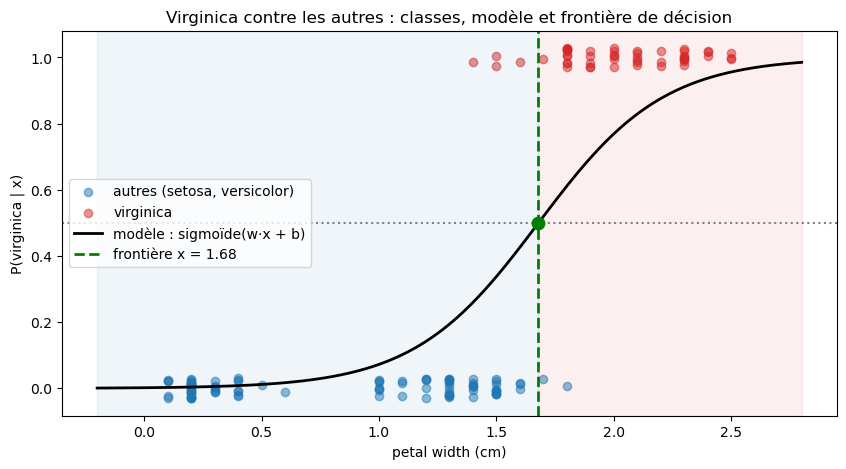

In [21]:
xs = np.linspace(X[feature].min() - 0.3, X[feature].max() + 0.3, 400)
xs_df = pd.DataFrame(xs, columns=[feature])
proba = clf.predict_proba(xs_df)[:, 1]

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Les classes sur la droite 1D (jitter vertical pour voir les points superposés)
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.03, 0.03, size=len(X))
ax.scatter(X[y == 0][feature], np.zeros((y == 0).sum()) + jitter[y == 0],
           c="tab:blue", alpha=0.5, label="autres (setosa, versicolor)")
ax.scatter(X[y == 1][feature], np.ones((y == 1).sum()) + jitter[y == 1],
           c="tab:red", alpha=0.5, label="virginica")

# 2. Le graphe du modèle : sigmoïde P(virginica | x)
ax.plot(xs, proba, "k-", lw=2, label="modèle : sigmoïde(w·x + b)")

# 3. La frontière de décision : x tel que sigmoïde = 0.5
ax.axhline(0.5, color="gray", linestyle=":")
ax.axvline(seuil, color="green", linestyle="--", lw=2, label=f"frontière x = {seuil:.2f}")
ax.scatter([seuil], [0.5], c="green", s=80, zorder=5)

# Zones de décision
ax.axvspan(xs.min(), seuil, color="tab:blue", alpha=0.07)
ax.axvspan(seuil, xs.max(), color="tab:red", alpha=0.07)

ax.set_xlabel(feature); ax.set_ylabel("P(virginica | x)")
ax.set_title("Virginica contre les autres : classes, modèle et frontière de décision")
ax.legend(loc="center left"); plt.show()

# vérification que la frontière est bien le point où P = 0.5

In [77]:
print("P(virginica | seuil) =", clf.predict_proba(pd.DataFrame([[seuil]], columns=[feature]))[0, 1])
print("Prédiction juste en dessous :", clf.predict(pd.DataFrame([[seuil - 0.01]], columns=[feature]))[0])
print("Prédiction juste au-dessus  :", clf.predict(pd.DataFrame([[seuil + 0.01]], columns=[feature]))[0])

P(virginica | seuil) = 0.5
Prédiction juste en dessous : 0
Prédiction juste au-dessus  : 1


# exemples mal classés visibles sur la figure

In [78]:
pred_test = clf.predict(Xte)
mal = Xte[pred_test != yte]
print("Exemples de test mal classés :")
print(pd.concat([mal, yte[pred_test != yte].rename("vraie classe")], axis=1))

Exemples de test mal classés :
     petal width (cm)  vraie classe
133               1.5             1
134               1.4             1


# variation de la frontière selon la partition

Frontière : moyenne = 1.669, écart-type = 0.019, min = 1.634, max = 1.720


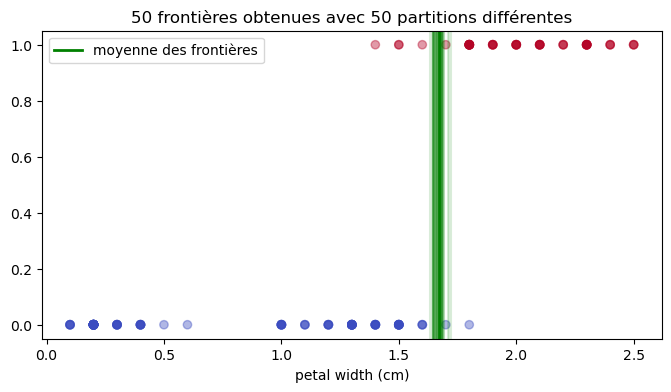

In [22]:
seuils = []
for seed in range(50):
    Xa, _, ya, _ = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)
    m = LogisticRegression().fit(Xa, ya)
    seuils.append(-m.intercept_[0] / m.coef_[0][0])

print(f"Frontière : moyenne = {np.mean(seuils):.3f}, écart-type = {np.std(seuils):.3f}, "
      f"min = {np.min(seuils):.3f}, max = {np.max(seuils):.3f}")

plt.figure(figsize=(8, 4))
for s in seuils:
    plt.axvline(s, color="green", alpha=0.15)
plt.scatter(X[feature], y, c=y, cmap="coolwarm", alpha=0.4)
plt.axvline(np.mean(seuils), color="green", lw=2, label="moyenne des frontières")
plt.xlabel(feature); plt.title("50 frontières obtenues avec 50 partitions différentes")
plt.legend(); plt.show()

# frontière pour les différents attributs et classes cibles

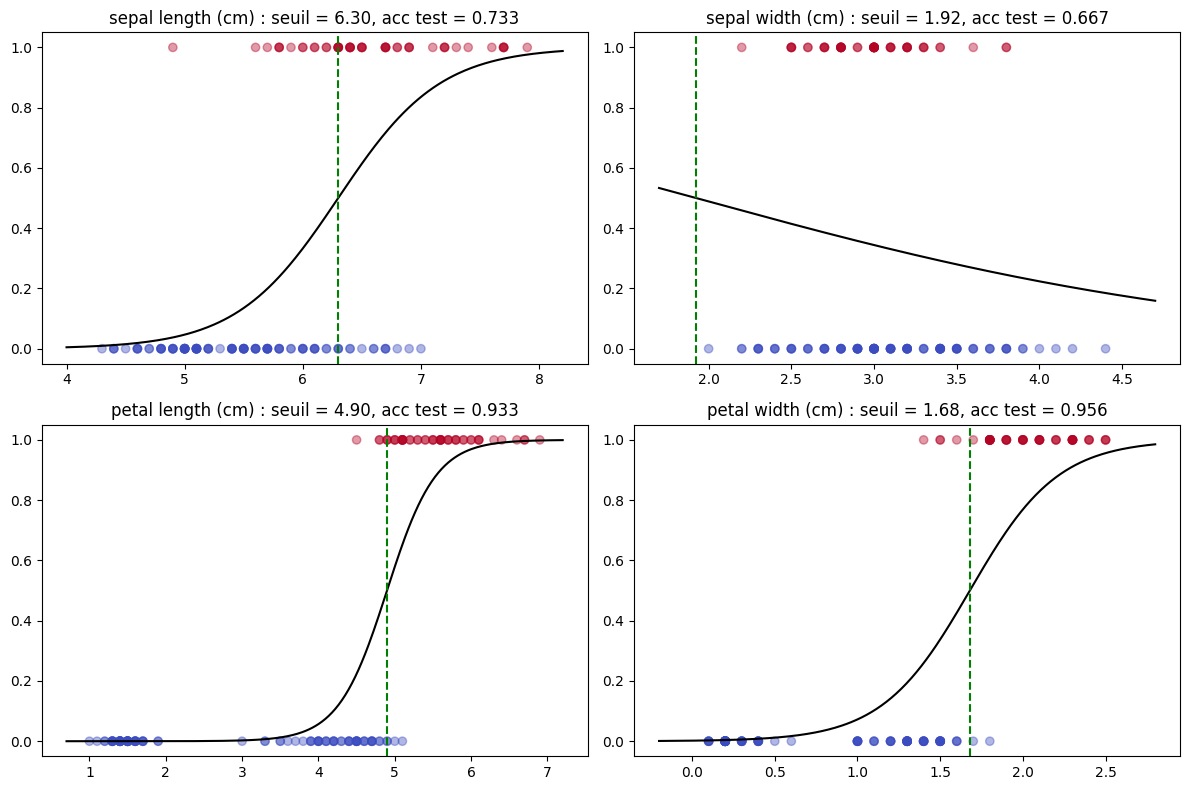

In [80]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.ravel(), iris.feature_names):
    Xf = iris.data[[feat]]
    Xa, _, ya, _ = train_test_split(Xf, y, test_size=0.3, stratify=y, random_state=42)
    m = LogisticRegression().fit(Xa, ya)
    s = -m.intercept_[0] / m.coef_[0][0]
    g = np.linspace(Xf[feat].min() - 0.3, Xf[feat].max() + 0.3, 300)
    ax.scatter(Xf[feat], y, c=y, cmap="coolwarm", alpha=0.4)
    ax.plot(g, m.predict_proba(pd.DataFrame(g, columns=[feat]))[:, 1], "k-")
    ax.axvline(s, color="green", linestyle="--")
    ax.set_title(f"{feat} : seuil = {s:.2f}, acc test = {m.score(Xf.loc[Xte.index], yte):.3f}")
plt.tight_layout(); plt.show()

# cas versicolor (la frontière unique ne suffit pas)

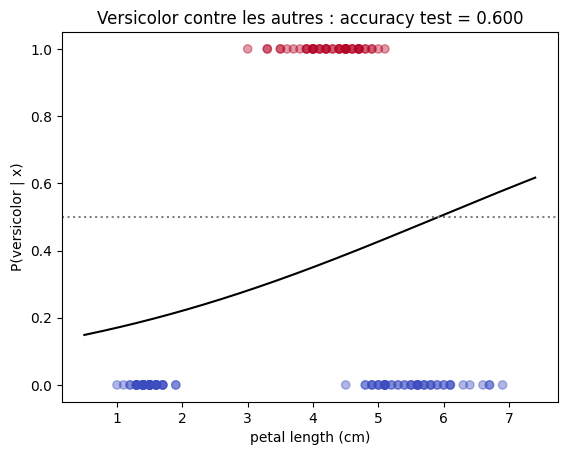

w = 0.3218876125374807 | seuil = 5.9195112797339595


In [81]:
y_ver = (iris.target == 1).astype(int)
f2 = "petal length (cm)"
Xa, Xb, ya, yb = train_test_split(iris.data[[f2]], y_ver, test_size=0.3, stratify=y_ver, random_state=42)
m = LogisticRegression(C=100, max_iter=1000).fit(Xa, ya)
g = np.linspace(0.5, 7.4, 300)

plt.scatter(iris.data[f2], y_ver, c=y_ver, cmap="coolwarm", alpha=0.4)
plt.plot(g, m.predict_proba(pd.DataFrame(g, columns=[f2]))[:, 1], "k-")
plt.axhline(0.5, color="gray", linestyle=":")
plt.xlabel(f2); plt.ylabel("P(versicolor | x)")
plt.title(f"Versicolor contre les autres : accuracy test = {m.score(Xb, yb):.3f}")
plt.show()
print("w =", m.coef_[0][0], "| seuil =", -m.intercept_[0] / m.coef_[0][0])

### Commentaires sur les résultats de 1.3

**Lecture de la figure (virginica contre les autres, largeur des pétales)**
- Les points bleus (setosa et versicolor, classe 0) sont à gauche, les rouges (virginica, classe 1) à droite. Un décalage vertical aléatoire (jitter) a été ajouté pour voir les points superposés.
- La sigmoïde est P(virginica | x) = σ(3.755·x − 6.306). Elle est proche de 0 pour x < 1 cm et de 1 pour x > 2.5 cm. 
- La frontière de décision est x = 6.306 / 3.755 ≈ 1.68 cm, point où la sigmoïde coupe la droite P = 0.5 (point vert). À gauche, le modèle prédit « autre » ; à droite, « virginica ». En 1D, le classifieur est donc un simple seuil.
- Les deux classes se chevauchent entre environ 1.4 et 1.8 cm : des virginica sont à gauche de la frontière, des « autres » (versicolor) à droite. C'est dans cette zone, et seulement là, que se trouvent les erreurs.

**Erreurs de classification**
- Sur le jeu de test, les deux exemples mal classés (index 133 et 134) sont des virginica de largeur 1.5 et 1.4 cm, donc à gauche de la frontière : ce sont des faux négatifs. Il n'y a aucun faux positif sur le test, ce qui est cohérent avec la matrice [[30, 0], [2, 13]].
- Sur les 150 exemples, sur la figure on voit en plus deux points bleus à droite de la frontière (largeurs 1.7 et 1.8 cm). Ce sont des erreurs d'entraînement, car il n'y a aucun faux positif sur le test. Au total, environ 6 exemples sont mal classés sur 150 : 4 virginica rouges à gauche de la frontière, 2 points bleus à droite.
- Ces exemples ne peuvent pas être corrigés par un autre réglage de la régression logistique : en 1D, des classes différentes ont des largeurs voisines.

**Stabilité de la frontière (50 partitions)**
- La frontière vaut en moyenne 1.669 cm, avec un écart-type de 0.019 cm (min 1.634, max 1.720). sur la figure on voit des traits verts très serrés, alors que la zone de chevauchement fait environ 0.4 cm de large.
- Les largeurs sont mesurées au dixième de cm. Tout seuil compris entre 1.6 et 1.7 donne donc les mêmes prédictions, et seul un seuil qui dépasse 1.7 (cas extrême : 1.720) modifie la décision pour les exemples de largeur 1.7.
- La frontière étant stable, elle n'explique pas la variabilité de l'accuracy de test observée en 1.2 (de 0.91 à 1.00). L'explication la plus plausible est la composition du jeu de test : environ 6 exemples difficiles sur 150, dont environ 1.8 tombent en moyenne dans un test de 45 exemples (30 %). Cela donne une accuracy moyenne proche de 1 − 1.8/45 ≈ 0.96, et le nombre d'exemples difficiles qui tombent dans le test varie d'une partition à l'autre.

**Autres attributs (virginica contre les autres, une partition)**

| attribut | seuil | accuracy test |
|---|---|---|
| sepal length | 6.30 | 0.733 |
| sepal width | 1.92 | 0.667 |
| petal length | 4.90 | 0.933 |
| petal width | 1.68 | 0.956 |

- Les attributs de pétales sont meilleurs que ceux de sépales, comme dans les moyennes de 1.2 (une seule partition ici, d'où de petits écarts avec les moyennes).
- **Sepal length** : les nuages se recouvrent largement entre 5.5 et 7 cm. La frontière à 6.30 laisse beaucoup d'erreurs des deux côtés.
- **Sepal width** : la sigmoïde est presque plate et décroissante. Le seuil (1.92) est inférieur à toutes les valeurs observées (minimum 2.0), donc le modèle prédit toujours « autre ». Son accuracy (0.667) est exactement celle du classifieur trivial : cet attribut n'apporte aucune information utile pour cette tâche.
- **Raideur des sigmoïdes** : celle de petal length est plus raide que celle de petal width, bien que son accuracy soit plus faible. La raideur dépend de l'échelle de l'attribut (petal length varie sur environ 6 cm, petal width sur environ 2.4 cm).
- **Petal length** : les points rouges et bleus se mélangent entre environ 4.5 et 5.1 cm autour de la frontière (4.90), ce qui explique l'accuracy un peu plus basse que pour petal width.

**Cas versicolor (longueur des pétales)**
- Versicolor occupe l'intervalle central (de 3.0 à 5.1 cm environ), entre setosa (petites valeurs) et virginica (grandes valeurs). La classe cible est donc entourée par la classe 0 des deux côtés.
- La sigmoïde apprise est monotone et croissante (de ≈ 0.15 à ≈ 0.62). Elle ne dépasse 0.5 que vers 5.9 cm, là où il n'y a plus de versicolor, seulement des virginica à grands pétales.
- Conséquence : le modèle ne prédit « versicolor » que pour ces grandes valeurs, donc à tort. L'accuracy de test est de 0.600, inférieure au classifieur trivial (0.667). Avec 45 exemples de test, cela correspond à 27 bonnes réponses, soit 3 de moins que le classifieur trivial.
- Ce n'est pas un problème de réglage : une sigmoïde sur un seul attribut ne peut représenter qu'une seule frontière, alors qu'un intervalle en demande deux. Il faut un terme quadratique, un autre modèle ou plusieurs attributs (cf. l'expérience polynomiale).

**Conclusion**
- Un modèle de régression logistique 1D est entièrement décrit par deux nombres, w et b, et se lit comme un seuil x = −b/w.
- La frontière est stable d'une partition à l'autre ; ce sont les exemples difficiles qui varient dans le test.
- La visualisation nous permet de prévoir la qualité du modèle avant tout calcul : chevauchement faible → bonne accuracy (petal width), chevauchement total → modèle trivial (sepal width), classe intermédiaire → modèle inadapté (versicolor).

### 1.4 Do the same as above for other cases 
Use of different iris features as discrimants, different iris species and also different arguments for 'LogisticRegression', like 'tol' or 'max-iter'.

For instance, tol = 0.14 gives an interesting result.

In [23]:
import warnings
from sklearn.exceptions import ConvergenceWarning

def ajuste(feat, k, test_size=0.3, seed=42, scale=False, **params):
    """Ajuste une régression logistique 1D (espèce k contre les autres) sur l'attribut feat."""
    Xf = iris.data[[feat]]
    yk = (iris.target == k).astype(int)
    Xtr, Xte, ytr, yte = train_test_split(Xf, yk, test_size=test_size, stratify=yk, random_state=seed)
    lr = LogisticRegression(**params)
    m = make_pipeline(StandardScaler(), lr) if scale else lr
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter("always")
        m.fit(Xtr, ytr)
    converge = not any(issubclass(x.category, ConvergenceWarning) for x in w)
    # coefficients exprimés dans l'unité d'origine de l'attribut
    if scale:
        sc = m[0]
        wv = lr.coef_[0][0] / sc.scale_[0]
        bv = lr.intercept_[0] - lr.coef_[0][0] * sc.mean_[0] / sc.scale_[0]
    else:
        wv, bv = lr.coef_[0][0], lr.intercept_[0]
    seuil = -bv / wv if wv != 0 else np.nan
    return dict(modele=m, lr=lr, w=wv, b=bv, seuil=seuil, converge=converge,
                n_iter=int(lr.n_iter_[0]), acc_train=m.score(Xtr, ytr),
                acc_test=m.score(Xte, yte), Xf=Xf, yk=yk, Xtr=Xtr, Xte=Xte, yte=yte)

# toutes les espèces et tous les attributs (3 × 4 graphiques)

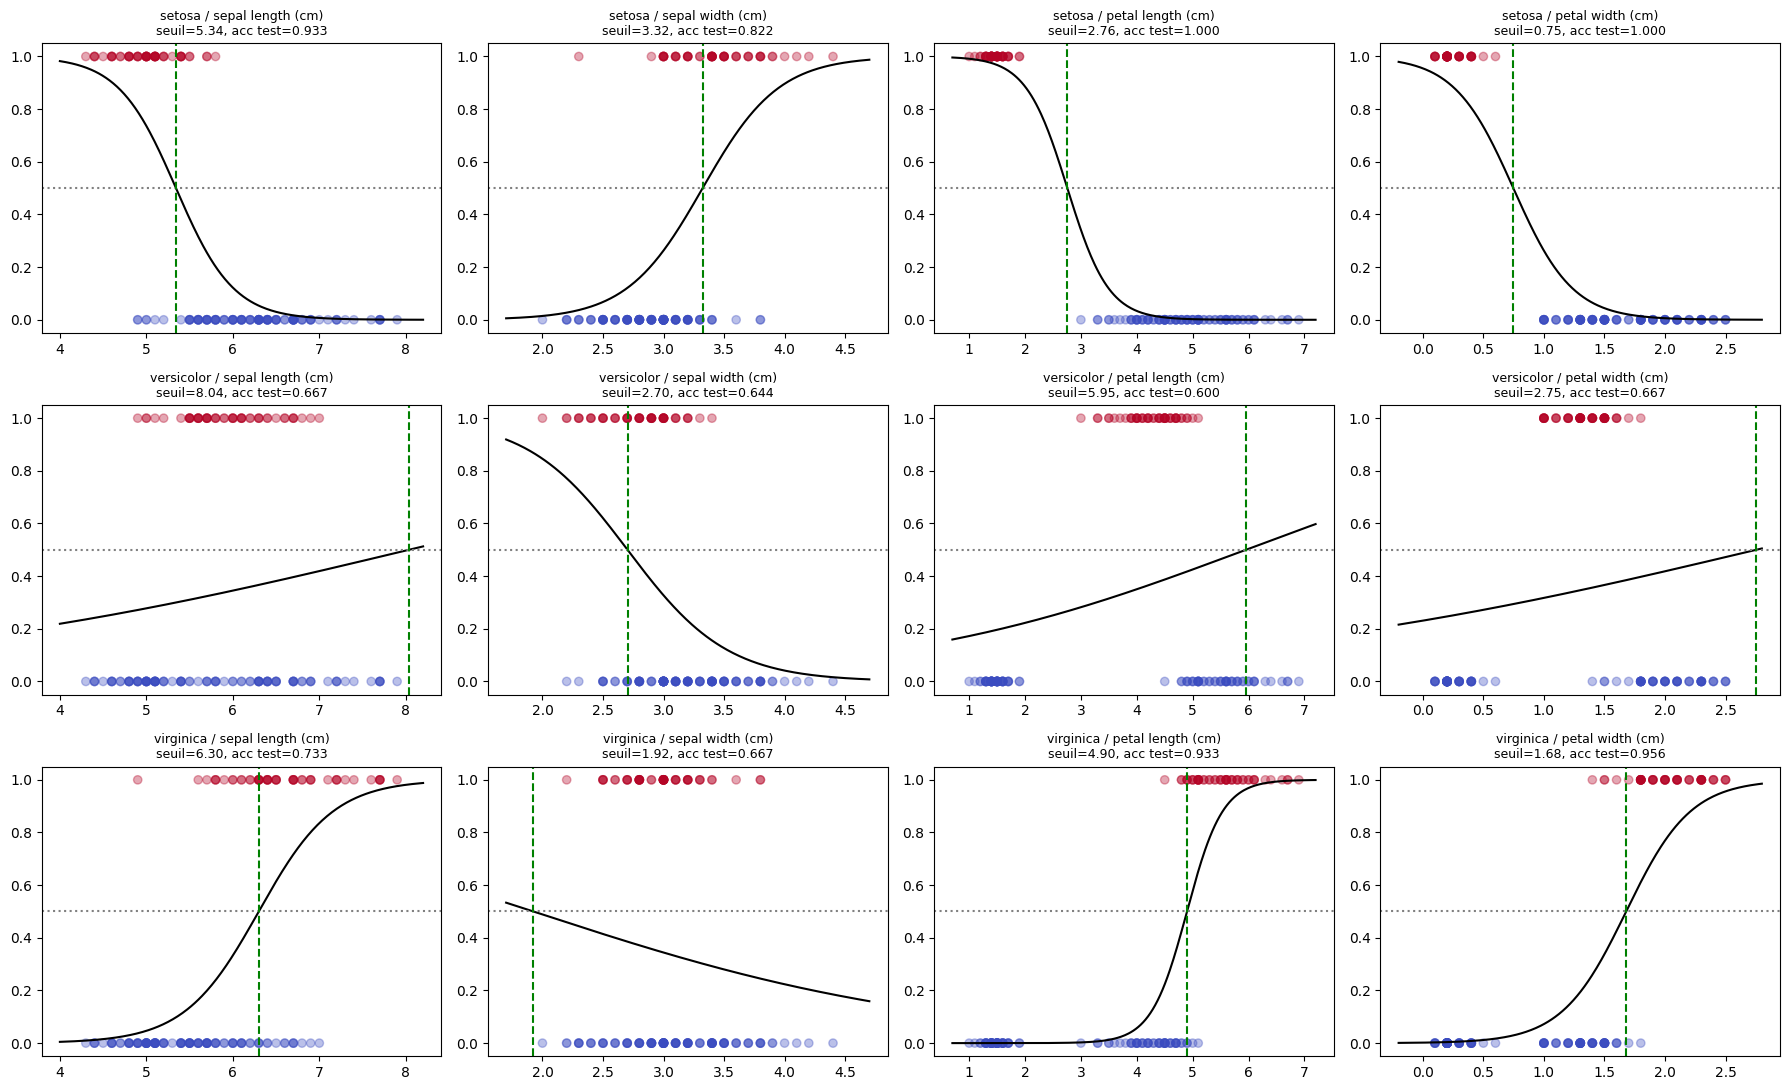

In [123]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for k, esp in enumerate(iris.target_names):
    for j, feat in enumerate(iris.feature_names):
        r = ajuste(feat, k)
        ax = axes[k, j]
        g = pd.DataFrame(np.linspace(r["Xf"][feat].min() - 0.3, r["Xf"][feat].max() + 0.3, 300), columns=[feat])
        ax.scatter(r["Xf"][feat], r["yk"], c=r["yk"], cmap="coolwarm", alpha=0.35)
        ax.plot(g[feat], r["modele"].predict_proba(g)[:, 1], "k-")
        ax.axhline(0.5, color="gray", linestyle=":")
        ax.axvline(r["seuil"], color="green", linestyle="--")
        ax.set_title(f"{esp} / {feat}\nseuil={r['seuil']:.2f}, acc test={r['acc_test']:.3f}",
                     fontsize=9)
plt.tight_layout(); plt.show()

# effet de tol (virginica, largeur des pétales)

In [24]:
lignes = []
for tol in [1e-8, 1e-4, 1e-2, 0.05, 0.14, 0.3, 1, 10]:
    r = ajuste("petal width (cm)", 2, tol=tol, max_iter=1000)
    lignes.append({"tol": tol, "n_iter": r["n_iter"], "w": r["w"], "b": r["b"],
                   "seuil": r["seuil"], "acc_train": r["acc_train"], "acc_test": r["acc_test"]})
pd.DataFrame(lignes).round(3)

,tol,n_iter,w,b,seuil,acc_train,acc_test
0,0.00,12,3.755,-6.307,1.679,0.962,0.956
1,0.00,8,3.755,-6.306,1.679,0.962,0.956
2,0.01,5,3.296,-5.487,1.665,0.962,0.956
3,0.05,3,2.178,-3.409,1.565,0.943,0.956
4,0.14,1,0.514,-0.857,1.667,0.962,0.956
5,0.30,0,0.000,0.000,NaN,0.667,0.667
6,1.00,0,0.000,0.000,NaN,0.667,0.667
7,10.00,0,0.000,0.000,NaN,0.667,0.667


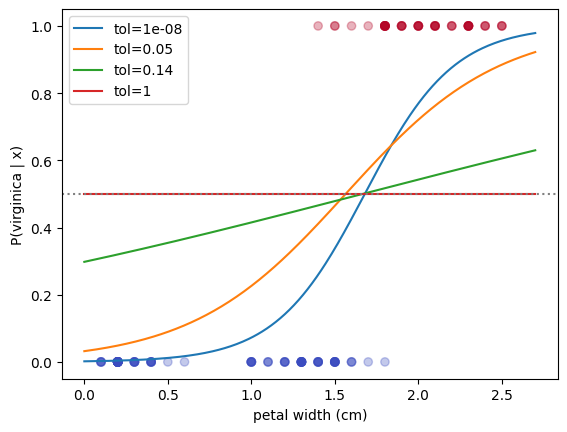

In [85]:
# Sigmoïdes correspondantes
feat = "petal width (cm)"
g = pd.DataFrame(np.linspace(0, 2.7, 300), columns=[feat])
X1, y1 = iris.data[[feat]], (iris.target == 2).astype(int)
plt.scatter(X1[feat], y1, c=y1, cmap="coolwarm", alpha=0.3)
for tol in [1e-8, 0.05, 0.14, 1]:
    r = ajuste(feat, 2, tol=tol, max_iter=1000)
    plt.plot(g[feat], r["modele"].predict_proba(g)[:, 1], label=f"tol={tol}")
plt.axhline(0.5, color="gray", linestyle=":"); plt.legend()
plt.xlabel(feat); plt.ylabel("P(virginica | x)"); plt.show()

# tol selon l'espèce (accuracy de test et seuil)

In [86]:
tols = [1e-8, 1e-2, 0.14, 0.5, 2]
for feat in ["petal width (cm)", "petal length (cm)"]:
    acc = pd.DataFrame(index=iris.target_names, columns=[f"tol={t}" for t in tols], dtype=float)
    seu = acc.copy()
    for k, esp in enumerate(iris.target_names):
        for t in tols:
            r = ajuste(feat, k, tol=t, max_iter=1000)
            acc.loc[esp, f"tol={t}"], seu.loc[esp, f"tol={t}"] = r["acc_test"], r["seuil"]
    print(feat, "\nAccuracy de test :\n", acc.round(3), "\nSeuil :\n", seu.round(2), "\n")

petal width (cm) 
Accuracy de test :
             tol=1e-08  tol=0.01  tol=0.14  tol=0.5  tol=2
setosa          1.000     1.000     0.667    0.667  0.667
versicolor      0.667     0.667     0.667    0.667  0.667
virginica       0.956     0.956     0.956    0.667  0.667 
Seuil :
             tol=1e-08  tol=0.01  tol=0.14  tol=0.5  tol=2
setosa           0.75      0.75     -0.33    -0.33    NaN
versicolor       2.75      2.78     -1.30      NaN    NaN
virginica        1.68      1.66      1.67      NaN    NaN 

petal length (cm) 
Accuracy de test :
             tol=1e-08  tol=0.01  tol=0.14  tol=0.5  tol=2
setosa          1.000     1.000     1.000    0.667  0.667
versicolor      0.600     0.600     0.667    0.667  0.667
virginica       0.933     0.933     0.956    0.667  0.667 
Seuil :
             tol=1e-08  tol=0.01  tol=0.14  tol=0.5  tol=2
setosa           2.76      2.80      2.82    -0.12    NaN
versicolor       5.95      5.94     -0.43      NaN    NaN
virginica        4.90      4.90

# tol avec et sans standardisation
La condition d'arrêt de lbfgs porte sur le gradient, donc dépend de l'échelle des attributs.

In [87]:
lignes = []
for scale in [False, True]:
    for tol in [1e-8, 0.01, 0.14, 0.5]:
        r = ajuste("petal width (cm)", 2, scale=scale, tol=tol, max_iter=1000)
        lignes.append({"standardisation": scale, "tol": tol, "n_iter": r["n_iter"],
                       "seuil": r["seuil"], "acc_test": r["acc_test"]})
pd.DataFrame(lignes).round(3)

,standardisation,tol,n_iter,seuil,acc_test
0,False,0.00,12,1.679,0.956
1,False,0.01,5,1.665,0.956
2,False,0.14,1,1.667,0.956
3,False,0.50,0,NaN,0.667
4,True,0.00,11,1.678,0.956
5,True,0.01,6,1.682,0.956
6,True,0.14,2,1.572,0.956
7,True,0.50,0,NaN,0.667


# effet de max_iter (avec détection de non-convergence)

In [88]:
lignes = []
for mi in [1, 2, 3, 5, 10, 20, 100]:
    r = ajuste("petal width (cm)", 2, max_iter=mi, tol=1e-8)
    lignes.append({"max_iter": mi, "n_iter": r["n_iter"], "convergé": r["converge"],
                   "w": r["w"], "seuil": r["seuil"],
                   "acc_train": r["acc_train"], "acc_test": r["acc_test"]})
pd.DataFrame(lignes).round(3)

,max_iter,n_iter,convergé,w,seuil,acc_train,acc_test
0,1,1,False,0.514,1.667,0.962,0.956
1,2,2,False,1.542,1.079,0.743,0.644
2,3,3,False,2.178,1.565,0.943,0.956
3,5,5,False,3.296,1.665,0.962,0.956
4,10,10,False,3.755,1.679,0.962,0.956
5,20,12,True,3.755,1.679,0.962,0.956
6,100,12,True,3.755,1.679,0.962,0.956


# effet du solveur

In [89]:
lignes = []
for solver in ["lbfgs", "newton-cg", "liblinear", "saga"]:
    r = ajuste("petal width (cm)", 2, solver=solver, max_iter=5000)
    lignes.append({"solver": solver, "n_iter": r["n_iter"], "convergé": r["converge"],
                   "w": r["w"], "b": r["b"], "seuil": r["seuil"], "acc_test": r["acc_test"]})
pd.DataFrame(lignes).round(3)

,solver,n_iter,convergé,w,b,seuil,acc_test
0,lbfgs,8,True,3.755,-6.306,1.679,0.956
1,newton-cg,5,True,3.755,-6.307,1.679,0.956
2,liblinear,4,True,2.266,-3.627,1.601,0.956
3,saga,50,True,3.752,-6.301,1.679,0.956


# cas séparable (setosa) et cas intermédiaire (versicolor) avec max_iter et tol

In [90]:
for esp_k, feat in [(0, "petal length (cm)"), (1, "petal length (cm)")]:
    print("Espèce :", iris.target_names[esp_k], "| attribut :", feat)
    for params in [dict(tol=1e-8, max_iter=1000), dict(tol=0.14, max_iter=1000),
                   dict(tol=1e-8, max_iter=3)]:
        r = ajuste(feat, esp_k, **params)
        print(f"  {str(params):38s} | w={r['w']:7.2f} | seuil={r['seuil']:6.2f} "
              f"| convergé={r['converge']} | acc test={r['acc_test']:.3f}")

Espèce : setosa | attribut : petal length (cm)
  {'tol': 1e-08, 'max_iter': 1000}       | w=  -2.71 | seuil=  2.76 | convergé=True | acc test=1.000
  {'tol': 0.14, 'max_iter': 1000}        | w=  -1.75 | seuil=  2.82 | convergé=True | acc test=1.000
  {'tol': 1e-08, 'max_iter': 3}          | w=  -0.53 | seuil=  0.46 | convergé=False | acc test=0.667
Espèce : versicolor | attribut : petal length (cm)
  {'tol': 1e-08, 'max_iter': 1000}       | w=   0.32 | seuil=  5.95 | convergé=True | acc test=0.600
  {'tol': 0.14, 'max_iter': 1000}        | w=  -0.11 | seuil= -0.43 | convergé=True | acc test=0.667
  {'tol': 1e-08, 'max_iter': 3}          | w=  -0.02 | seuil= -8.62 | convergé=False | acc test=0.667


# 2. Binary Classifiers on Artificial 1D Datasets

Do the same as in Exercise 1 but with artificial 1D datasets (of 1D points labeled over two classes).

### 2.1 Build the datasets
The artificial dataset can be obtained by sampling each class by a Gaussian function, 
for instance using the following code:

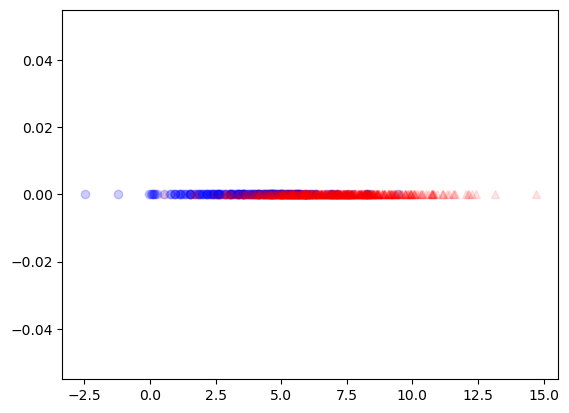

In [26]:
def gaussian_1D_generation(mean, standard_deviation,  N):
    np.random.seed(42) # makes the generator predictable
    X = (standard_deviation * np.random.randn(N) + mean).reshape(-1,1)
    return X

X_A = gaussian_1D_generation(4, 2, 300) 
X_B = gaussian_1D_generation(7, 2, 900)

Y_A = np.zeros(300, dtype=int)
Y_B = np.ones(900, dtype=int)

X = np.concatenate((X_A, X_B))
Y = np.concatenate((Y_A, Y_B))

X_train, X_valid, y_train, y_valid = train_test_split(X, Y, test_size=0.33, random_state=42)
plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bo", alpha = 0.2)
plt.plot(X_train[y_train == 1], y_train[y_train == 1] - 1, "r^", alpha= 0.1)
plt.show()

### 2.2  Generalization with a Logistic Regression
 
Obtain a generalization/model (based on a sigmoid-like score function) of the obtained 1D classification problem 
by directly using `LogisticRegression` of `scikit` (with at least a partition train/test).

Accuracy train : 0.8308457711442786
Accuracy valid : 0.8232323232323232
Matrice de confusion (valid) :
 [[ 47  53]
 [ 17 279]]
w = 0.851, b = -3.502
Frontière de décision : x = 4.115


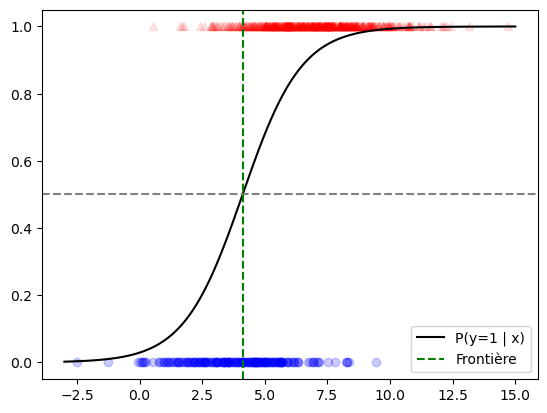

In [27]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

y_pred_train = clf.predict(X_train)
y_pred_valid = clf.predict(X_valid)

print("Accuracy train :", accuracy_score(y_train, y_pred_train))
print("Accuracy valid :", accuracy_score(y_valid, y_pred_valid))
print("Matrice de confusion (valid) :\n", confusion_matrix(y_valid, y_pred_valid))

# Paramètres appris
w = clf.coef_[0][0]
b = clf.intercept_[0]
print(f"w = {w:.3f}, b = {b:.3f}")
print(f"Frontière de décision : x = {-b / w:.3f}")

# 4. Visualisation de la sigmoïde apprise
x_grid = np.linspace(-3, 15, 500).reshape(-1, 1)
proba = clf.predict_proba(x_grid)[:, 1]   # P(classe = 1 | x)

plt.plot(X_train[y_train == 0], y_train[y_train == 0], "bo", alpha=0.2)
plt.plot(X_train[y_train == 1], y_train[y_train == 1], "r^", alpha=0.1)
plt.plot(x_grid, proba, "k-", label="P(y=1 | x)")
plt.axhline(0.5, color="gray", linestyle="--")
plt.axvline(-b / w, color="green", linestyle="--", label="Frontière")
plt.legend()
plt.show()

### **Interprétation**
On  entraîne le modele avec `LogisticRegression` de scikit-learn sur `X_train`, puis évalué sur `X_valid` (partition 67 % / 33 %).

- **Généralisation** : les accuracy d'entraînement (83,1 %) et de validation (82,3 %) sont très proches, il n'y a donc pas de surapprentissage.
- **Modèle appris** : le modèle estime P(y=1 | x) = σ(wx + b). Comme w > 0, la probabilité d'appartenir à la classe 1 augmente avec x, ce qui correspond aux données (classe 0 centrée en 4, classe 1 centrée en 7).
- **Frontière de décision** : elle se situe à x ≈ 4,1, nettement à gauche du milieu des deux moyennes (5,5). Cela vient du déséquilibre des classes (300 contre 900) : la classe 1 étant plus fréquente, le modèle la favorise. Cette valeur est proche de la frontière théorique de Bayes (≈ 4,03).
- **Limite de l'accuracy** : la classe 1 représente 75 % des données, un classifieur qui prédirait toujours 1 aurait déjà environ 75 % d'accuracy. Le modèle n'apporte donc qu'un gain modéré en apparence.
- **Erreurs par classe** : la classe 1 est très bien reconnue (rappel ≈ 94 %, 279/296), alors que la classe 0 l'est mal (rappel ≈ 47 %, 47/100). Plus de la moitié des points de la classe 0 sont classés à tort en classe 1.
- **Origine des erreurs** : elles ne viennent pas d'un défaut du modèle mais du chevauchement intrinsèque des deux gaussiennes (même écart-type σ = 2, moyennes séparées de seulement 3). La zone de transition de la sigmoïde est large (x de 1 à 8 environ), ce qui limite l'accuracy atteignable à environ 82-83 %.

**Conclusion** : la régression logistique apprend une frontière quasi optimale et généralise bien. Pour améliorer la détection de la classe minoritaire, on pourrait utiliser `class_weight="balanced"`, ce qui rapprocherait la frontière de 5,5 et augmenterait le rappel de la classe 0, au prix d'une accuracy globale plus faible.

### 2.3 Plot the classes and the generalization/model
Do the same as in Exercise 1.3

w = 0.851, b = -3.502, seuil = 4.115


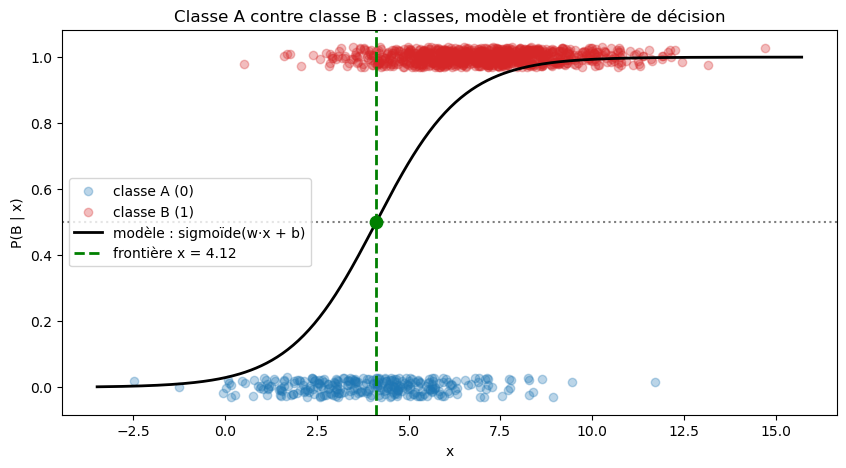

70 erreurs sur 396 exemples de validation
Faux positifs (A prédit B) : 53
Faux négatifs (B prédit A) : 17


In [ ]:
# Paramètres du modèle appris en 2.2
w, b = clf.coef_[0][0], clf.intercept_[0]
seuil = -b / w
print(f"w = {w:.3f}, b = {b:.3f}, seuil = {seuil:.3f}")

xs = np.linspace(X.min() - 1, X.max() + 1, 400).reshape(-1, 1)
proba = clf.predict_proba(xs)[:, 1]

fig, ax = plt.subplots(figsize=(10, 5))

# Les classes sur la droite 1D (jitter vertical pour voir les points superposés)
rng = np.random.default_rng(0)
jitter = rng.uniform(-0.03, 0.03, size=len(X))
ax.scatter(X[Y == 0, 0], np.zeros((Y == 0).sum()) + jitter[Y == 0],
           c="tab:blue", alpha=0.3, label="classe A (0)")
ax.scatter(X[Y == 1, 0], np.ones((Y == 1).sum()) + jitter[Y == 1],
           c="tab:red", alpha=0.3, label="classe B (1)")

# Le graphe du modèle : sigmoïde P(B | x)
ax.plot(xs, proba, "k-", lw=2, label="modèle : sigmoïde(w·x + b)")

# La frontière de décision : x tel que sigmoïde = 0.5
ax.axhline(0.5, color="gray", linestyle=":")
ax.axvline(seuil, color="green", linestyle="--", lw=2, label=f"frontière x = {seuil:.2f}")
ax.scatter([seuil], [0.5], c="green", s=80, zorder=5)


ax.set_xlabel("x"); ax.set_ylabel("P(B | x)")
ax.set_title("Classe A contre classe B : classes, modèle et frontière de décision")
ax.legend(loc="center left"); plt.show()

# Exemples de validation mal classés
pred_valid = clf.predict(X_valid)
erreurs = pred_valid != y_valid
print(f"{erreurs.sum()} erreurs sur {len(y_valid)} exemples de validation")
print("Faux positifs (A prédit B) :", ((pred_valid == 1) & (y_valid == 0)).sum())
print("Faux négatifs (B prédit A) :", ((pred_valid == 0) & (y_valid == 1)).sum())

# Commentaires sur les résultats de 2.3
Les points bleus (classe A, 0) sont à gauche et les rouges (classe B, 1) à droite. Un décalage vertical aléatoire (jitter) a été ajouté pour voir les points superposés. La classe B est trois fois plus nombreuse que la classe A (900 contre 300), ce qui se voit à la densité des points rouges.
La sigmoïde est P(B | x) = σ(0.851·x − 3.502). Elle est proche de 0 pour x < 0 et de 1 pour x > 10.
La frontière de décision est x = 3.502 / 0.851 ≈ 4.12, point où la sigmoïde coupe la droite P = 0.5 (point vert). À gauche, le modèle prédit A ; à droite, B. En 1D, le classifieur est donc un simple seuil.
Les deux classes se chevauchent sur une zone très large, d'environ 1 à 8 : des points A sont à droite de la frontière et des points B à gauche. La zone de transition de la sigmoïde est donc beaucoup plus étalée qu'en 1.3.

La frontière (4.12) n'est pas au milieu des deux moyennes (5.5) mais décalée vers la classe A. Cela vient du déséquilibre : B étant trois fois plus fréquente, le modèle la favorise. Elle est proche de la frontière théorique de Bayes (≈ 4.03), calculée avec les vraies lois des données.

Sur le jeu de validation, la matrice [[47, 53], [17, 279]] donne 70 erreurs sur 396 : 53 faux positifs (points A à droite de la frontière, prédits B) et 17 faux négatifs (points B à gauche de la frontière, prédits A).
Contrairement à 1.3, les erreurs sont nombreuses et surtout de type faux positif : environ 17 % des exemples sont mal classés (accuracy de 0.83 en entraînement, 0.82 en validation).
Ces erreurs ne peuvent pas être corrigées en changeant le réglage de la régression logistique : en 1D, des exemples de classes différentes ont des valeurs identiques, car les gaussiennes se chevauchent. Le modèle est déjà quasi optimal.

Comparaison avec l'exercice 1.3

En 1.3 (petal width), le chevauchement est faible (environ 0.4 cm) et l'accuracy proche de 0.96. Ici, il est important (σ = 2 pour une distance de 3 entre les moyennes) et l'accuracy plafonne vers 0.82-0.83.
Le classifieur trivial (toujours B) obtient 0.75. Le modèle ne fait donc que 7 à 8 points mieux, alors qu'en 1.3 il faisait beaucoup mieux que le classifieur trivial (0.667).

### 2.4 Do the same as above for other datasets
Use different sizes of datasets, different balances between the two classes, different Gaussians, and different configurations of overlaps between classes.

Make sure you understand the results.

On répète la même démarche (génération, séparation 67 % / 33 % stratifiée, LogisticRegression, graphe, frontière) pour 9 configurations : tailles différentes, équilibres différents, gaussiennes différentes, chevauchements différents.

                                        N   % B      w  seuil  Bayes  acc train  acc valid  triviale  rappel A  rappel B
1. référence                       1200.0  75.0  0.737   3.93   4.04      0.836      0.818      0.75      0.49      0.93
2. classes équilibrées             1200.0  50.0  0.762   5.41   5.50      0.770      0.778      0.50      0.74      0.82
3. très déséquilibré (5 %/95 %)    1200.0  95.0  0.747   1.48   1.57      0.951      0.947      0.95      0.00      1.00
4. petit jeu (60 points)             60.0  75.0  0.987   4.02   4.04      0.850      0.800      0.75      0.40      0.93
5. grand jeu (120 000 points)    120000.0  75.0  0.755   4.04   4.04      0.825      0.825      0.75      0.51      0.93
6. bien séparées                   1200.0  50.0  3.016   4.93   5.00      0.998      1.000      0.50      1.00      1.00
7. fort chevauchement              1200.0  50.0  0.248   5.39   5.50      0.604      0.606      0.50      0.58      0.63
8. mêmes moyennes, σ différents 

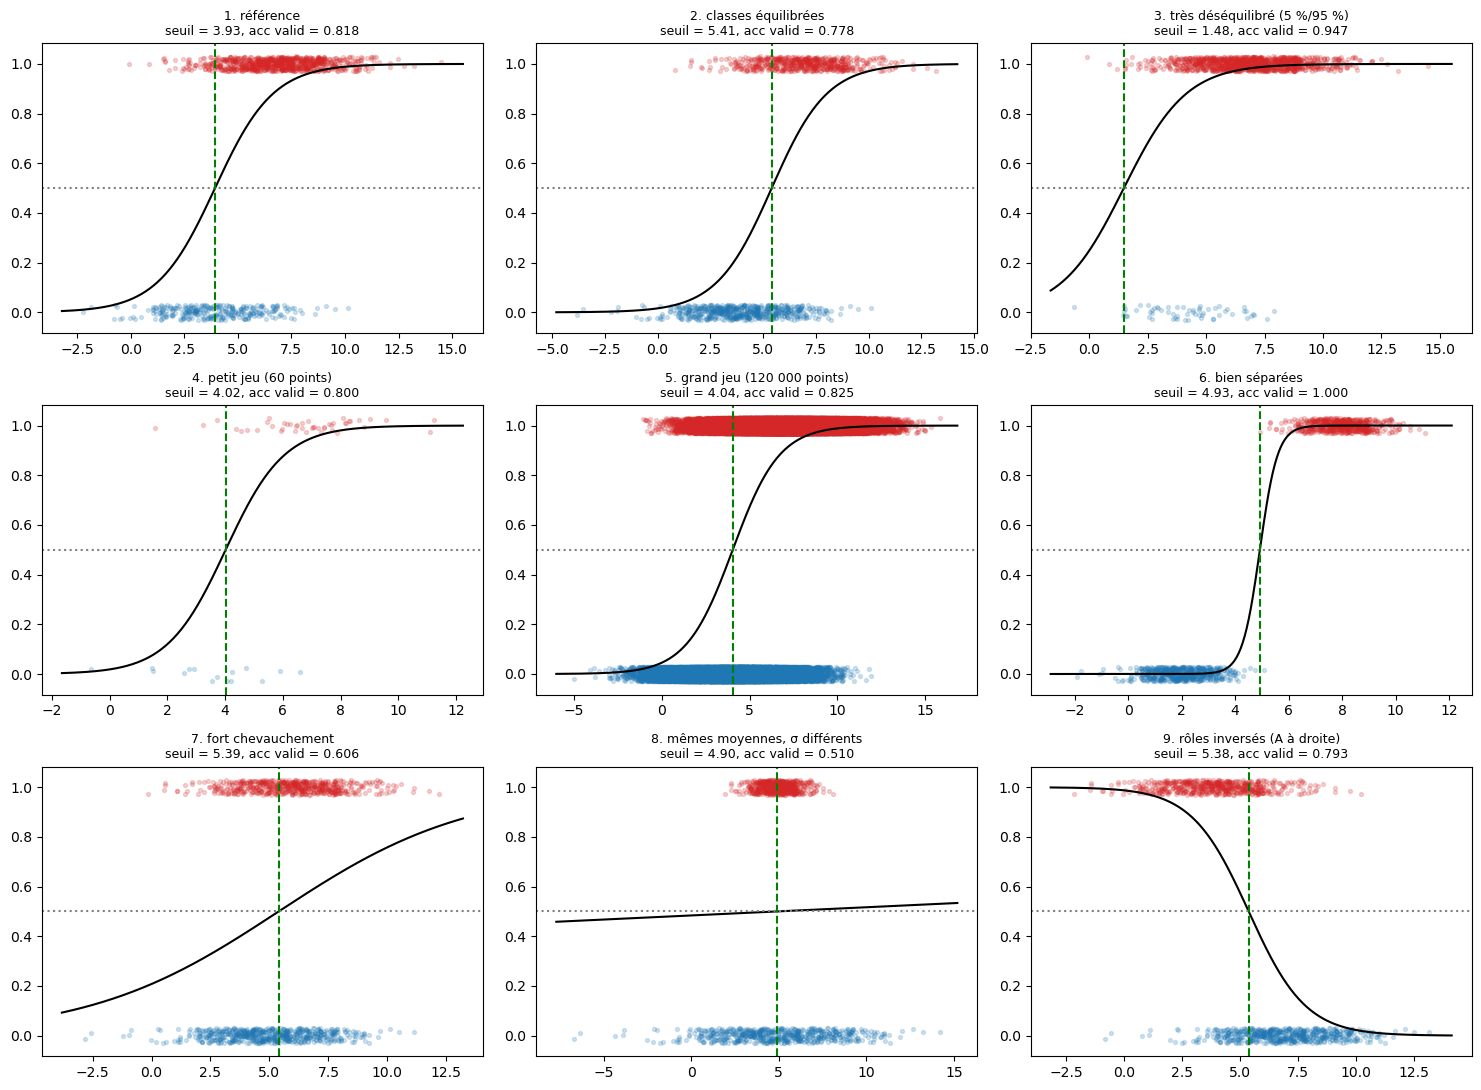

In [36]:
def gaussian_1D_generation(mean, standard_deviation, N, seed):
    rng = np.random.default_rng(seed)  # graine différente par classe
    return (standard_deviation * rng.standard_normal(N) + mean).reshape(-1, 1)


# (moyenne A, écart-type A, N_A, moyenne B, écart-type B, N_B)
scenarios = {
    "1. référence":                    (4, 2, 300, 7, 2, 900),
    "2. classes équilibrées":          (4, 2, 600, 7, 2, 600),
    "3. très déséquilibré (5 %/95 %)": (4, 2, 60, 7, 2, 1140),
    "4. petit jeu (60 points)":        (4, 2, 15, 7, 2, 45),
    "5. grand jeu (120 000 points)":   (4, 2, 30000, 7, 2, 90000),
    "6. bien séparées":                (2, 1, 600, 8, 1, 600),
    "7. fort chevauchement":           (5, 2, 600, 6, 2, 600),
    "8. mêmes moyennes, σ différents": (5, 3, 600, 5, 1, 600),
    "9. rôles inversés (A à droite)":  (7, 2, 600, 4, 2, 600),
}


def run_experiment(muA, sdA, NA, muB, sdB, NB, seed=42):
    X = np.concatenate((gaussian_1D_generation(muA, sdA, NA, 0),
                        gaussian_1D_generation(muB, sdB, NB, 1)))
    Y = np.concatenate((np.zeros(NA, dtype=int), np.ones(NB, dtype=int)))
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, Y, test_size=0.33, random_state=seed, stratify=Y)
    clf = LogisticRegression().fit(X_train, y_train)
    w, b = clf.coef_[0][0], clf.intercept_[0]
    pred = clf.predict(X_valid)
    cm = confusion_matrix(y_valid, pred, labels=[0, 1])
    # frontière de Bayes (valable seulement si les deux écarts-types sont égaux)
    bayes = None
    if sdA == sdB and muA != muB:
        bayes = (muA + muB) / 2 + sdA**2 * np.log(NA / NB) / (muB - muA)
    return dict(X=X, Y=Y, clf=clf, w=w, b=b, seuil=-b / w, bayes=bayes, cm=cm,
                acc_train=clf.score(X_train, y_train),
                acc_valid=clf.score(X_valid, y_valid),
                trivial=max(NA, NB) / (NA + NB),
                recall_A=cm[0, 0] / cm[0].sum(), recall_B=cm[1, 1] / cm[1].sum())


results = {name: run_experiment(*p) for name, p in scenarios.items()}

# Tableau récapitulatif
tab = pd.DataFrame({
    name: {"N": len(r["Y"]), "% B": round(100 * r["Y"].mean()),
           "w": round(r["w"], 3), "seuil": round(r["seuil"], 2),
           "Bayes": None if r["bayes"] is None else round(r["bayes"], 2),
           "acc train": round(r["acc_train"], 3), "acc valid": round(r["acc_valid"], 3),
           "triviale": round(r["trivial"], 3),
           "rappel A": round(r["recall_A"], 2), "rappel B": round(r["recall_B"], 2)}
    for name, r in results.items()}).T
print(tab.to_string())

# Graphes : classes, sigmoïde et frontière pour chaque configuration
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, (name, r) in zip(axes.ravel(), results.items()):
    X, Y = r["X"], r["Y"]
    rng = np.random.default_rng(0)
    jit = rng.uniform(-0.03, 0.03, size=len(X))
    ax.scatter(X[Y == 0, 0], jit[Y == 0], c="tab:blue", alpha=0.2, s=8)
    ax.scatter(X[Y == 1, 0], 1 + jit[Y == 1], c="tab:red", alpha=0.2, s=8)
    xs = np.linspace(X.min() - 1, X.max() + 1, 400).reshape(-1, 1)
    ax.plot(xs, r["clf"].predict_proba(xs)[:, 1], "k-")
    ax.axhline(0.5, color="gray", linestyle=":")
    ax.axvline(r["seuil"], color="green", linestyle="--")
    ax.set_title(f"{name}\nseuil = {r['seuil']:.2f}, acc valid = {r['acc_valid']:.3f}", fontsize=9)
plt.tight_layout(); plt.show()

Dans tous les cas, le modèle est une sigmoïde et le classifieur un simple seuil x = −b/w. Seuls changent la position du seuil, la raideur de la sigmoïde (w) et la qualité des prédictions.
Lorsque les deux écarts-types sont égaux, la valeur de w est proche de (μB − μA) / σ². C'est bien ce qu'on observe : 0.75 attendu pour les configurations 1 à 5 (obtenu de 0.737 à 0.762, sauf le petit jeu), 0.25 attendu pour la configuration 7 (obtenu 0.248).

Classes équilibrées (2) : le seuil (5.41) est quasiment au milieu des deux moyennes (5.5) et les deux classes sont reconnues de façon comparable (rappels 0.74 et 0.82). L'accuracy (0.778) est supérieure de près de 28 points au classifieur trivial (0.50) et proche de la valeur théorique Φ(0.75) ≈ 0.773.
Déséquilibre 75 % / 25 % (1) : le seuil se décale vers la classe minoritaire (3.93, proche de Bayes 4.04). Le rappel de A tombe à 0.49 contre 0.93 pour B.
Déséquilibre extrême 5 % / 95 % (3) : le seuil (1.48) est tout à fait à gauche, dans la queue de la classe A. Aucun exemple A de validation (une vingtaine) n'est à gauche du seuil, donc le rappel de A est de 0.00 : le modèle prédit toujours B. L'accuracy (0.947) est exactement celle du classifieur trivial : elle est élevée mais le modèle est inutile pour détecter A. Avec class_weight="balanced", le seuil remonte à 5.38 et le rappel de A passe à 0.65 (rappel de B : 0.78), au prix d'une accuracy plus basse (0.775). L'accuracy n'est donc pas une bonne mesure quand les classes sont déséquilibrées : il faut regarder la matrice de confusion et les rappels.


Grand jeu (5, 120 000 points) : le seuil (4.04) est identique à la frontière de Bayes, w (0.755) est proche de la valeur théorique 0.75, et les accuracy d'entraînement et de validation sont égales (0.825). Cette valeur est la limite théorique pour ces lois : aucun classifieur ne peut faire mieux sur ces données.
Petit jeu (4, 60 points) : la validation ne contient que 20 exemples, donc un seul exemple change l'accuracy de 5 points. L'écart entre entraînement (0.850) et validation (0.800) n'est pas significatif ; sur 50 partitions différentes, l'accuracy de validation varie de 0.70 à 0.90 (moyenne 0.841, écart-type 0.049). La sigmoïde est plus raide (w = 0.987 au lieu de 0.75) car le modèle s'ajuste aux quelques points disponibles. Le seuil (4.02) est proche de Bayes, mais cela ne garantit pas qu'il soit stable d'un tirage à l'autre.
Plus le jeu est grand, plus les estimations sont stables et proches des valeurs théoriques. Les erreurs ne disparaissent pas pour autant : elles viennent du chevauchement, pas du manque de données.

Classes bien séparées (6, moyennes distantes de 6 pour σ = 1) : accuracy de 1.000 en validation, sigmoïde très raide, seuil (4.93) au milieu des deux moyennes. La valeur de w (3.016) est inférieure à la valeur théorique 6 : la régularisation L2 par défaut de LogisticRegression (C = 1) empêche w de croître indéfiniment quand les données sont presque séparables.
Fort chevauchement (7, moyennes distantes de 1 pour σ = 2) : la sigmoïde est presque plate (w = 0.248, la probabilité varie lentement de 0.1 à 0.9 sur plus de 10 unités). L'accuracy (0.606) est à peine supérieure au classifieur trivial (0.50) et proche de la limite théorique Φ(0.25) ≈ 0.60. Un modèle plus complexe ne ferait pas mieux, car l'information sur la classe est quasi absente.
Dans ces deux cas, la douceur de la sigmoïde mesure le recouvrement des classes : plus il est faible, plus la sigmoïde est raide.

Les deux classes ont la même moyenne (5) mais des écarts-types différents (3 et 1) : B est concentrée au centre et A est étalée autour. Aucun seuil unique ne les sépare : w ≈ 0.013, la sigmoïde est presque plate à 0.5, et le « seuil » (4.90) n'a pas de sens, car −b/w est très instable quand w est proche de 0.
L'accuracy (0.510) est celle du hasard (0.50). Comme pour le cas versicolor de 1.3, il faudrait deux frontières (environ 3.4 et 6.6, d'après les lois des deux classes), alors qu'une sigmoïde sur un seul attribut ne peut en représenter qu'une. Avec un terme quadratique (attributs x et x²), l'accuracy de validation passe à 0.768.

Si A est à droite de B, w devient négatif (−0.812) et la sigmoïde est décroissante, mais le seuil (5.38) et la qualité du modèle sont les mêmes qu'en 2 (accuracy 0.793 contre 0.778). L'écart de 1.5 point est de l'ordre de la fluctuation statistique avec 396 exemples de validation (environ 2 points). Le signe de w indique seulement de quel côté se trouve la classe 1.

Conclusion

Le modèle est toujours décrit par deux nombres, w et b. Pour deux gaussiennes de même écart-type, il retrouve presque exactement les paramètres théoriques (w ≈ (μB − μA) / σ²) et la frontière de Bayes.
La position de la frontière dépend de l'équilibre des classes, sa raideur du chevauchement, et la précision de l'estimation de la taille du jeu de données.
L'accuracy maximale atteignable est fixée par le chevauchement des classes, pas par le modèle : plus de données ou un réglage différent ne la dépassent pas.
Il faut comparer l'accuracy au classifieur trivial et regarder les rappels de chaque classe : une accuracy de 0.95 peut cacher un modèle qui ne détecte jamais la classe minoritaire (configuration 3).

# 3. Binary 2D Classifiers on the Iris Dataset
Do the same as in Exercise 1 but instead of using only one feature of the data (sepal length, sepal width, petal length, or petal width) <b>, use two of them as discriminant</b>.

### 3.1 Generalization with a Logistic Regression

On sépare les données en un jeu d'entraînement et un jeu de test, puis on apprend sur le premier et on mesure la performance sur le second. Un bon score sur le test mesure la capacité de généralisation. Un bon score sur le train seul peut cacher du surapprentissage.

On prend ici un problème binaire : Virginica contre le reste, avec les deux features pétale (longueur, largeur).

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix

iris = load_iris()
X = iris.data[:, [2, 3]]                 # petal length, petal width
y = (iris.target == 2).astype(int)       # 1 = virginica, 0 = autres

X_tr, X_te, y_tr, y_te = train_test_split( X, y, test_size=0.3, stratify=y, random_state=0)

clf = LogisticRegression()              
clf.fit(X_tr, y_tr)

print("w =", clf.coef_, " b =", clf.intercept_)
print("acc train :", accuracy_score(y_tr, clf.predict(X_tr)))
print("acc test  :", accuracy_score(y_te, clf.predict(X_te)))
print(confusion_matrix(y_te, clf.predict(X_te)))

w = [[2.52948988 2.00911813]]  b = [-15.6672472]
acc train : 0.9809523809523809
acc test  : 0.9333333333333333
[[27  3]
 [ 0 15]]


Expériences supplémentaires : effet de la taille du jeu d'entraînement et de la régularisation C

In [38]:
#  Variation de la cardinalité du train
for ts in [0.9, 0.7, 0.5, 0.3, 0.1]:
    scores = []
    for seed in range(30):
        Xa, Xb, ya, yb = train_test_split(X, y, test_size=ts, stratify=y, random_state=seed)
        m = LogisticRegression().fit(Xa, ya)
        scores.append(m.score(Xb, yb))
    print(f"test_size={ts}: acc test = {np.mean(scores):.3f} ± {np.std(scores):.3f}")

#  Variation de C (inverse de la force de régularisation)
for C in [0.001, 0.01, 0.1, 1, 10, 100, 1e4]:
    m = LogisticRegression(C=C, max_iter=1000).fit(X_tr, y_tr)
    print(f"C={C:>8}: |w|={np.linalg.norm(m.coef_):.2f}  "
          f"train={m.score(X_tr,y_tr):.3f}  test={m.score(X_te,y_te):.3f}")

test_size=0.9: acc test = 0.948 ± 0.026
test_size=0.7: acc test = 0.963 ± 0.016
test_size=0.5: acc test = 0.963 ± 0.020
test_size=0.3: acc test = 0.957 ± 0.027
test_size=0.1: acc test = 0.962 ± 0.044
C=   0.001: |w|=0.07  train=0.667  test=0.667
C=    0.01: |w|=0.40  train=0.848  test=0.756
C=     0.1: |w|=1.26  train=0.962  test=0.956
C=       1: |w|=3.23  train=0.981  test=0.933
C=      10: |w|=7.19  train=0.990  test=0.933
C=     100: |w|=15.80  train=0.990  test=0.933
C= 10000.0: |w|=100.00  train=1.000  test=0.933


### 3.2 Plot the classes on the plane, and the decision boundary of the generalization/model
1. Plot the classes on the 2D plane (corresponding to the two features, e.g. the petal width and the petal length).
2. Plot the decision boundary as a 1D separation line over the plane (the isocline where the score $sigmoid(x,y)=0.5$).
3. (subsidiary) Ask an IA how to plot this result in pseudo-3D with the score 2D $sigmoid$ as a surface.

Remark: again, this is the same as some examples shown in the course.

La frontière est l'ensemble des points où $w_0 x + w_1 y + b = 0$, car $\sigma(0)=0.5$. C'est donc une droite : $y = -(w_0 x + b)/w_1$. Les deux méthodes suivantes donnent le même résultat.

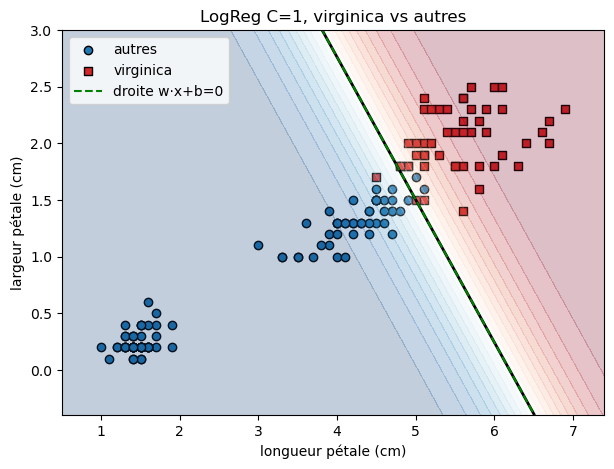

In [39]:
def plot_boundary(clf, X, y, xlabel, ylabel, title="", names=("autres", "virginica")):
    fig, ax = plt.subplots(figsize=(7, 5))
    # Nuage de points par classe
    for c, col, mk in [(0, "tab:blue", "o"), (1, "tab:red", "s")]:
        ax.scatter(X[y == c, 0], X[y == c, 1], c=col, marker=mk, label=names[c], edgecolor="k")

    # Grille pour calculer le score sigmoïde partout
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - .5, X[:, 0].max() + .5, 300),
        np.linspace(X[:, 1].min() - .5, X[:, 1].max() + .5, 300))
    P = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

    ax.contourf(xx, yy, P, levels=20, cmap="RdBu_r", alpha=.25)           # carte des probabilités
    ax.contour(xx, yy, P, levels=[0.5], colors="k", linewidths=2)          # 2. isocline 0.5

    # Vérification analytique : droite w·x + b = 0
    w, b = clf.coef_[0], clf.intercept_[0]
    xs = np.array(ax.get_xlim())
    ax.plot(xs, -(w[0] * xs + b) / w[1], "g--", label="droite w·x+b=0")

    ax.set_xlim(xx.min(), xx.max()); ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend()
    plt.show()

plot_boundary(clf, X, y, "longueur pétale (cm)", "largeur pétale (cm)", "LogReg C=1, virginica vs autres")

Voici ce qu'on obtiendrait en demandant à une IA, et qu'on peut utiliser tel quel :

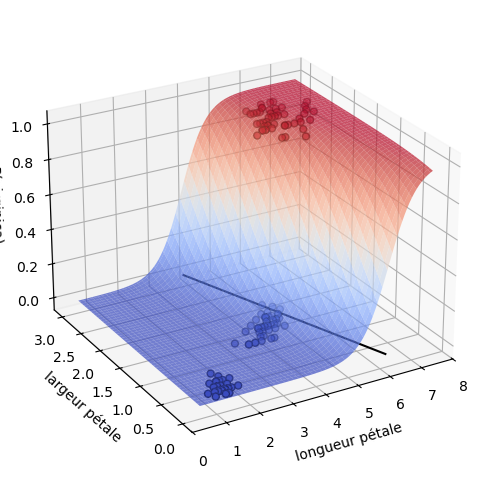

In [40]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

xx, yy = np.meshgrid(np.linspace(0.5, 7.5, 100), np.linspace(0, 3, 100))
P = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(xx, yy, P, cmap="coolwarm", alpha=.7, linewidth=0)
ax.contour(xx, yy, P, levels=[0.5], colors="k", offset=0)     # isocline projetée sur le plan z=0
ax.scatter(X[:, 0], X[:, 1], y, c=y, cmap="coolwarm", edgecolor="k", s=25)
ax.set_xlabel("longueur pétale"); ax.set_ylabel("largeur pétale"); ax.set_zlabel("P(virginica)")
ax.view_init(elev=25, azim=-120)
plt.show()

### 3.3 Do the same as above for other cases
Use different features as discrimants, different iris species and also different arguments for `LogisticRegression`.

setosa vs autres | petal length (cm) / petal width (cm) | {} -> train=1.000 test=1.000 w=[-2.39 -1.01] b=7.23


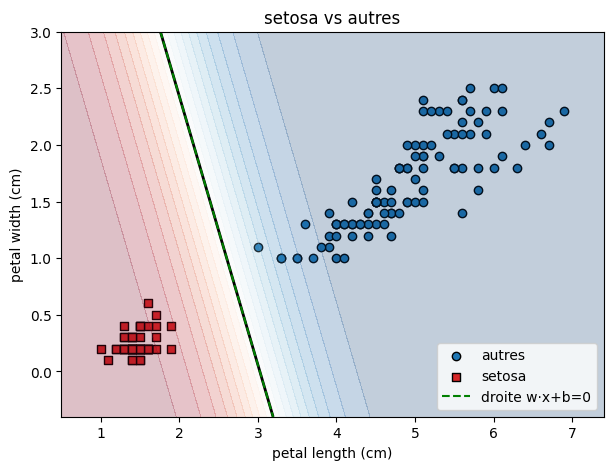

setosa vs autres | petal length (cm) / petal width (cm) | {'C': 100000.0} -> train=1.000 test=1.000 w=[ -6.64 -10.03] b=24.71


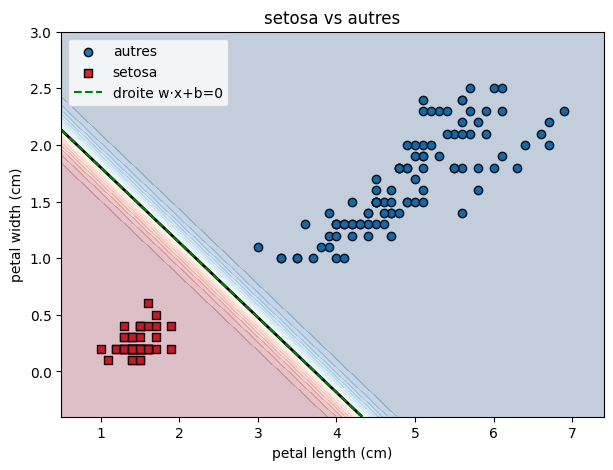

setosa vs autres | petal length (cm) / petal width (cm) | {'C': 0.01} -> train=1.000 test=1.000 w=[-0.45 -0.18] b=1.09


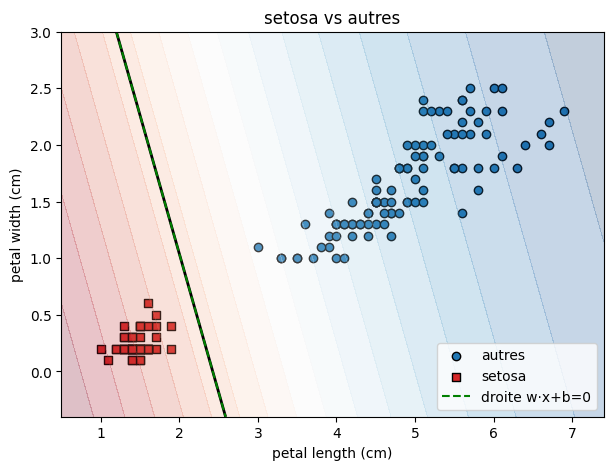

virginica vs versicolor | petal length (cm) / petal width (cm) | {} -> train=0.929 test=1.000 w=[2.5  2.02] b=-15.56


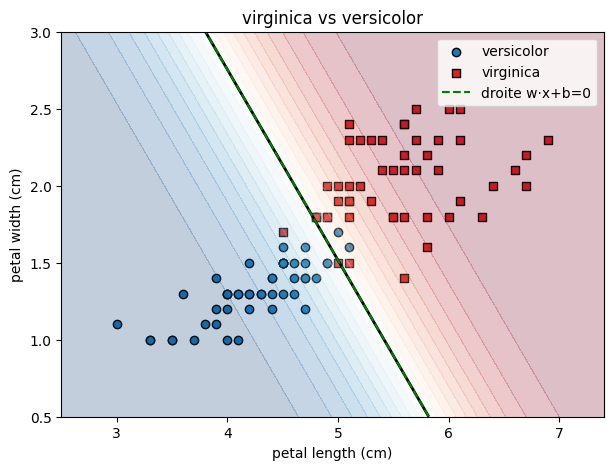

virginica vs versicolor | petal length (cm) / petal width (cm) | {'C': 10000.0} -> train=0.914 test=1.000 w=[5.34 9.08] b=-41.02


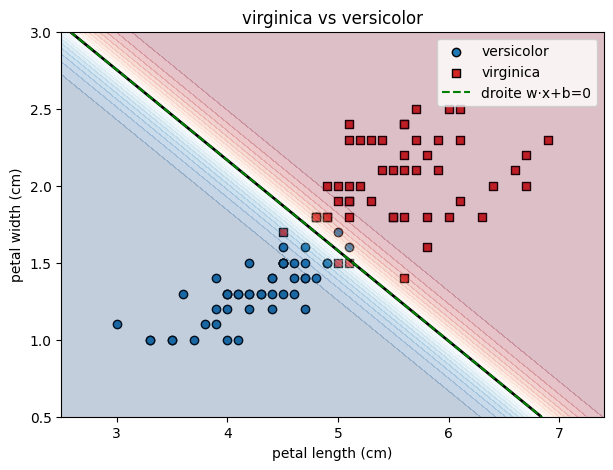

virginica vs versicolor | petal length (cm) / petal width (cm) | {'C': 0.05} -> train=0.943 test=1.000 w=[0.65 0.38] b=-3.78


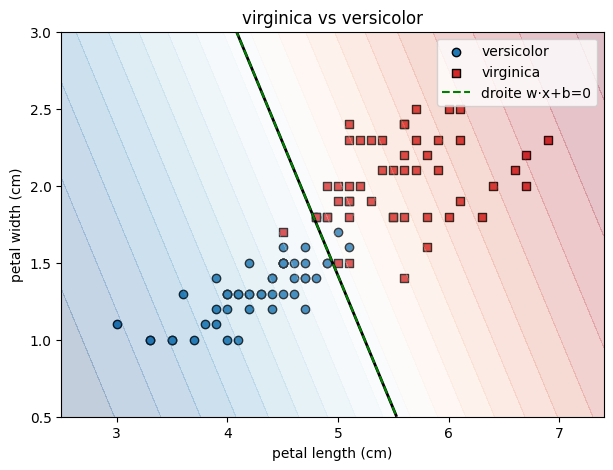

virginica vs versicolor | sepal length (cm) / sepal width (cm) | {} -> train=0.714 test=0.733 w=[ 1.56 -0.02] b=-9.64


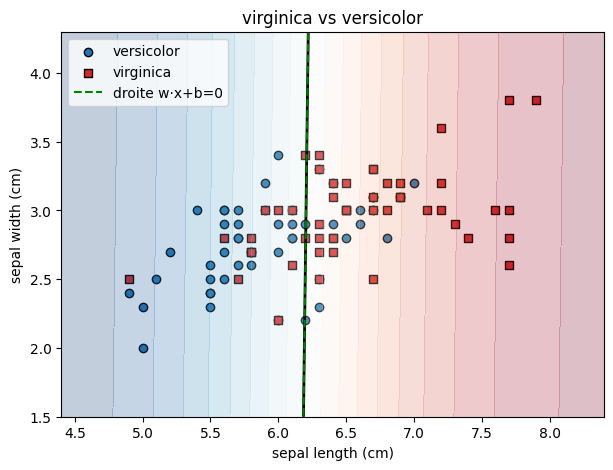

virginica vs autres | sepal length (cm) / petal width (cm) | {} -> train=0.971 test=0.933 w=[0.84 3.42] b=-10.98


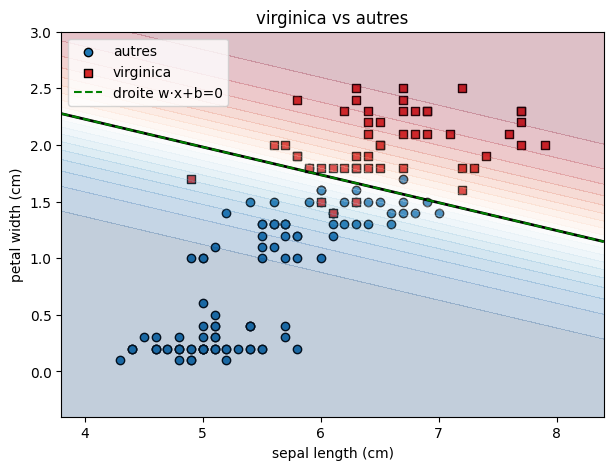

virginica vs versicolor | petal length (cm) / petal width (cm) | {'penalty': 'l1', 'solver': 'liblinear', 'C': 0.5} -> train=0.900 test=0.967 w=[0.02 2.38] b=-3.86


c:\Users\ismai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ismai\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


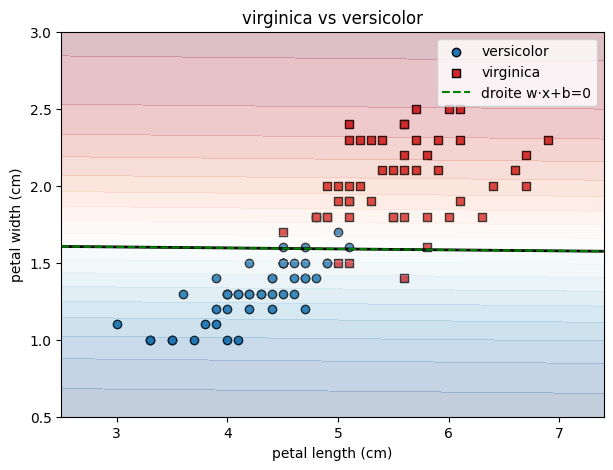

virginica vs versicolor | petal length (cm) / petal width (cm) | {'class_weight': {0: 1, 1: 5}} -> train=0.914 test=0.933 w=[3.05 2.79] b=-18.26


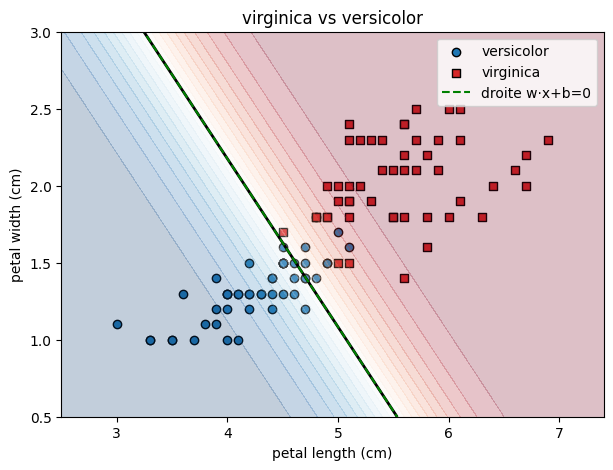

virginica vs versicolor | petal length (cm) / petal width (cm) | {'fit_intercept': False} -> train=0.629 test=0.767 w=[-0.59  1.89] b=0.00


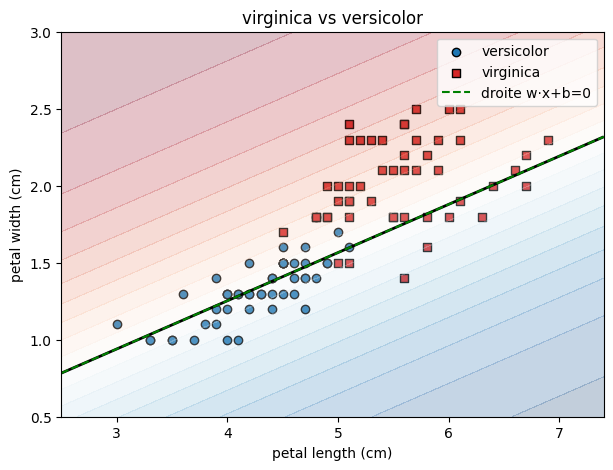

virginica vs versicolor | petal length (cm) / petal width (cm) | {} -> train=0.950 test=0.938 w=[1.63 1.03] b=-9.83


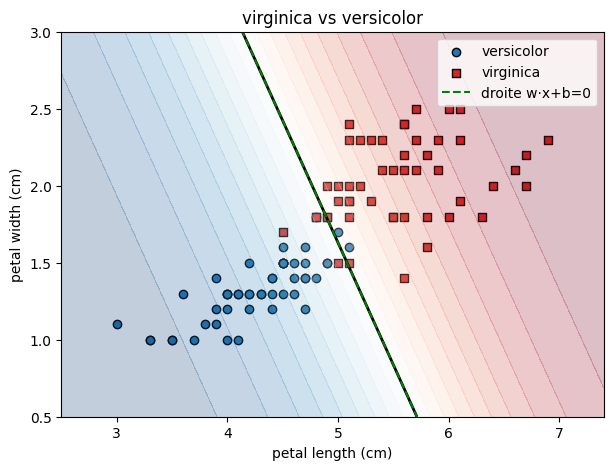

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [ ]:
feat_names = iris.feature_names
species = iris.target_names   # setosa, versicolor, virginica

def experiment(f1, f2, cls_pos, cls_neg=None, test_size=0.3, seed=0, **lr_kwargs):
    """cls_neg=None => cls_pos contre tout le reste ; sinon problème à 2 espèces seulement."""
    Xf = iris.data[:, [f1, f2]]
    if cls_neg is None:
        yy = (iris.target == cls_pos).astype(int); Xs = Xf
        names = ("autres", species[cls_pos])
    else:
        mask = np.isin(iris.target, [cls_neg, cls_pos])
        Xs, yy = Xf[mask], (iris.target[mask] == cls_pos).astype(int)
        names = (species[cls_neg], species[cls_pos])
    Xa, Xb, ya, yb = train_test_split(Xs, yy, test_size=test_size, stratify=yy, random_state=seed)
    m = LogisticRegression(max_iter=2000, **lr_kwargs).fit(Xa, ya)
    print(f"{names[1]} vs {names[0]} | {feat_names[f1]} / {feat_names[f2]} | {lr_kwargs} "
          f"-> train={m.score(Xa,ya):.3f} test={m.score(Xb,yb):.3f} w={m.coef_[0].round(2)} b={m.intercept_[0]:.2f}")
    plot_boundary(m, Xs, yy, feat_names[f1], feat_names[f2], f"{names[1]} vs {names[0]}", names)
    return m

#  setosa vs reste (pétales) : problème linéairement séparable
experiment(2, 3, 0)
experiment(2, 3, 0, C=1e5)       # quasi sans régularisation
experiment(2, 3, 0, C=0.01)      # très régularisé

# versicolor vs virginica (pétales) : classes qui se chevauchent
experiment(2, 3, 2, cls_neg=1)
experiment(2, 3, 2, cls_neg=1, C=1e4)
experiment(2, 3, 2, cls_neg=1, C=0.05)

#  mêmes espèces, features sépales : bien moins discriminants
experiment(0, 1, 2, cls_neg=1)

# virginica vs reste, features mixtes
experiment(0, 3, 2)

# autres arguments
experiment(2, 3, 2, cls_neg=1, penalty="l1", solver="liblinear", C=0.5)  # L1 : sparsité
experiment(2, 3, 2, cls_neg=1, class_weight={0: 1, 1: 5})                # poids de classes
experiment(2, 3, 2, cls_neg=1, fit_intercept=False)                      # sans biais
experiment(2, 3, 2, cls_neg=1, test_size=0.8)                            # très peu de données d'entraînement

# 4. Binary Classifiers on Artificial 2D Datasets

Do the same as in Exercise 1 but with 2D datasets and similarly as in Exercises with artificial datasets (of points labeled over two classes).


### 4.1 Build the datasets

2D artificial datasets can be obtained by just sampling rectangles: 
For instance, below is how to generate such a dataset made of:
- Class A consists of points drawn randomly in a rectangle of size (2,4) centered in (0,2)
- Class B consists of points drawn randomly in a rectangle of size (2,2) centered in (1,0)

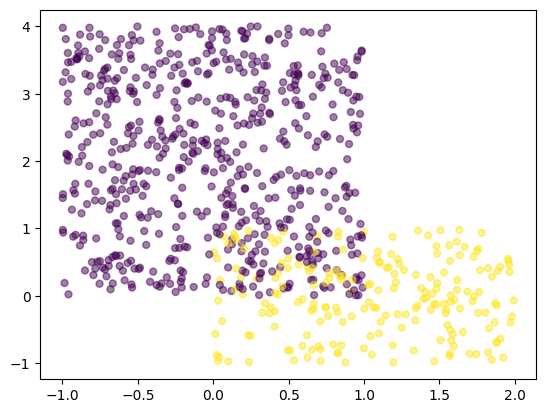

In [ ]:
NA = 900
NB = 300
geometry_A = (2,4)
center_A = (0,2)
geometry_B = (2,2)
center_B = (1,0)

XX_A = ( geometry_A[0] * (np.random.rand(NA) -.5) + center_A[0] ).reshape(-1,1)
XY_A = ( geometry_A[1] * (np.random.rand(NA) -.5) + center_A[1] ).reshape(-1,1)
X_A = np.concatenate( (XX_A, XY_A), axis=1 )
Y_A = np.array( [0 for i in range(NA)] ).reshape(-1,1)

XX_B = ( geometry_B[0] * (np.random.rand(NB) -.5) + center_B[0] ).reshape(-1,1)
XY_B = ( geometry_B[1] * (np.random.rand(NB) -.5) + center_B[1] ).reshape(-1,1)
X_B = np.concatenate( (XX_B, XY_B), axis=1 )
Y_B = np.array( [1 for i in range(NB)] ).reshape(-1,1)

X_dataset = np.concatenate((X_A, X_B), axis=0)
Y_dataset = np.concatenate((Y_A, Y_B), axis=0)

X_train, X_test, Y_train, Y_test = train_test_split(X_dataset, Y_dataset, test_size=0.33, random_state=42)

plt.scatter(X_train.T[0], X_train.T[1], alpha=.5, c=Y_train.T[0],s=25)
plt.show()

### 4.2 Generalization with a Logistic Regression
Obtain a generalization/model.

### 4.3 Plot the classes on the plane, and the decision boundary of the generalization/model
1. Plot the classes on the 2D plane.
2. Plot the decision boundary as a 1D separation line (Hint: try to use `matplotlib.pyplot.contourf`)

### 4.4 Do the same as above but with `SGDClassifer` instead of `LogisticRegression`

Of course, logistic regression is not the only way to obtain a generalization/model for classification.
For instance "SGDClassifier is a classifier that uses stochastic gradient descent to train linear models with regularization and early stopping. It supports various loss functions, penalties, learning rates, and regularization parameters."

### 4.5 Do the same as above for other datasets